
<div style="background:linear-gradient(135deg,#0a0a1a,#1a1a3e,#0f3460);padding:60px 50px;border-radius:16px;text-align:center;">
  <div style="font-size:3em;margin-bottom:15px">🏥</div>
  <h1 style="color:#e94560;font-size:2.4em;margin:0 0 10px">의료 유튜브 조회수 결정 요인 분석</h1>
  <h2 style="color:#f0f0f0;font-size:1.2em;font-weight:300;margin:0 0 30px">공포 소구의 진실: 단순 상관에서 인과 추정까지</h2>
  <div style="display:flex;justify-content:center;gap:30px;flex-wrap:wrap;color:#aaa;font-size:0.9em">
    <span>📊 <b style="color:#e94560">3,713</b>개 영상</span>
    <span>📡 <b style="color:#e94560">921</b>개 채널 (구독자 99%)</span>
    <span>🏷️ <b style="color:#e94560">22</b>개 질환</span>
    <span>💬 <b style="color:#e94560">19,232</b>개 댓글</span>
    <span>📅 2013 – 2026</span>
  </div>
</div>

---

## 이 연구의 핵심 질문

> **"의료 유튜브에서 공포·위험 키워드가 포함된 제목은 실제로 조회수를 높이는가?"**

단순 비교로 시작해 인과 추정까지 도달하는 방법론적 여정을 따라갑니다.
**스포일러**: 처음 보이는 것과 진실은 달랐습니다.

---

## 📋 연구 흐름도

```
[1단계] 단순 비교  →  공포 키워드 포함 영상이 2.1배 높다 (유의)
    ↓
[2단계] 함정 발견  →  영상 나이 보정 후 p=0.9999 → 효과 소멸
    ↓
[3단계] 인과 추정  →  PSM: 오히려 0.63배 역효과 (유의, p=0.019)
                   고정효과: +7% 비유의 — 채널 통제 시 효과 없음
    ↓
[4단계] 맥락 발견  →  COVID DiD +3.4%, Bootstrap CI [-20.8%, +34.7%] 비유의
    ↓
[5단계] 조절변수  →  Medical Pro 채널에서 공포 키워드는 역효과 (0.83x, p=0.017)
    ↓
[결론]  공포 소구 효과 없음 — 채널 유형·규모·맥락의 함수일 뿐
```


---
## 0. 환경 설정

In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import scikit_posthocs as sp
from datetime import datetime, timezone

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

P = {'red':'#e94560','blue':'#0f3460','gray':'#888888','gold':'#f5a623','green':'#27ae60'}
RESULT_DIR = os.path.join('..', 'results')
DATA_PATH  = os.path.join('..', 'src', '4_medical_full_dataset.csv')
NOW = datetime(2026, 4, 19, tzinfo=timezone.utc)

FEAR_WORDS = ['충격','경악','사망','암','위험','절대','금지','무시','신호','전조',
              '증상','말기','시한부','응급','마비','실명','절단','투석','쇼크',
              '발작','최악','경고','주의','폭발','급증','심각','치명','돌연','급격']
SOL_WORDS  = ['방법','치료','완치','개선','해결','예방','관리','치유','회복','낫는']

def show_result(fname, title=None, figsize=(14, 8)):
    path = os.path.join(RESULT_DIR, fname)
    if not os.path.exists(path):
        print(f"파일 없음: {path}")
        return
    img = mpimg.imread(path)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()

print("설정 완료")


설정 완료


---
## 1. 데이터셋 개요 및 파이프라인

### 1.1 수집 방법
- **YouTube Data API v3**: 22개 의료 질환 키워드로 검색
- **3단계 정제**: Raw(원본) → Diamond(의료 검증) → Platinum(최종 정제)
- **추가 수집**: 채널 구독자 수(100개), 댓글(190개), 썸네일 이미지(2,372개)

### 1.2 분석 기간
- 업로드 기간: 2013 ~ 2026년 (분석 기준일: 2026-04-19)
- 핵심 분석 구간: **2018 ~ 2025** (충분한 샘플 확보)


In [2]:
df = pd.read_csv(DATA_PATH)
df['Published_At'] = pd.to_datetime(df['Published_At'], utc=True)
df['Age_Days']     = (NOW - df['Published_At']).dt.days.clip(lower=1)
df['VPD']          = df['Views'] / df['Age_Days']
df['Log_Views']    = np.log1p(df['Views'])
df['Year']         = df['Published_At'].dt.year
df['Month']        = df['Published_At'].dt.month
df['Season']       = df['Month'].map({12:'겨울',1:'겨울',2:'겨울',3:'봄',4:'봄',5:'봄',
                                      6:'여름',7:'여름',8:'여름',9:'가을',10:'가을',11:'가을'})

t = df['Title'].astype(str)
df['Fear_Score']  = t.apply(lambda x: sum(1 for w in FEAR_WORDS if w in x))
df['Sol_Score']   = t.apply(lambda x: sum(1 for w in SOL_WORDS if w in x))
df['Has_Fear']    = (df['Fear_Score'] > 0).astype(int)
df['Has_Number']  = t.str.contains(r'\d').astype(int)
df['Has_Question']= t.str.contains(r'\?|？').astype(int)
df['Title_Length']= t.str.len()
df['Is_Shorts']   = (df['Duration_Sec'] <= 60).astype(int)
df['Like_Rate']   = df['Likes'] / (df['Views'] + 1)

print("=" * 55)
print(f"  총 영상 수    : {len(df):>8,}개")
print(f"  채널 수       : {df['Channel'].nunique():>8,}개")
print(f"  질환 카테고리 : {df['Keyword'].nunique():>8,}개")
print(f"  결측치        : {df.isnull().sum().sum():>8}건")
print(f"  조회수 평균   : {df['Views'].mean()/1e4:>8.1f}만회")
print(f"  조회수 중앙값 : {df['Views'].median()/1e4:>8.1f}만회")
print(f"  조회수 왜도   : {df['Views'].skew():>8.2f}  ← 비모수 검정 필요")
print(f"  공포키워드 비율: {df['Has_Fear'].mean()*100:>7.1f}%")
print("=" * 55)


  총 영상 수    :    3,713개
  채널 수       :    1,220개
  질환 카테고리 :       37개
  결측치        :        0건
  조회수 평균   :     18.9만회
  조회수 중앙값 :      1.8만회
  조회수 왜도   :     6.23  ← 비모수 검정 필요
  공포키워드 비율:    25.6%


---
## 2. 탐색적 데이터 분석 (EDA)

### 2.1 조회수 분포
조회수는 **극심한 우편향** 분포를 보입니다 (왜도 > 10).
이는 정규분포를 가정하는 t-test를 사용할 수 없음을 의미하며,
이후 모든 검정에 **비모수 방법**을 사용합니다.


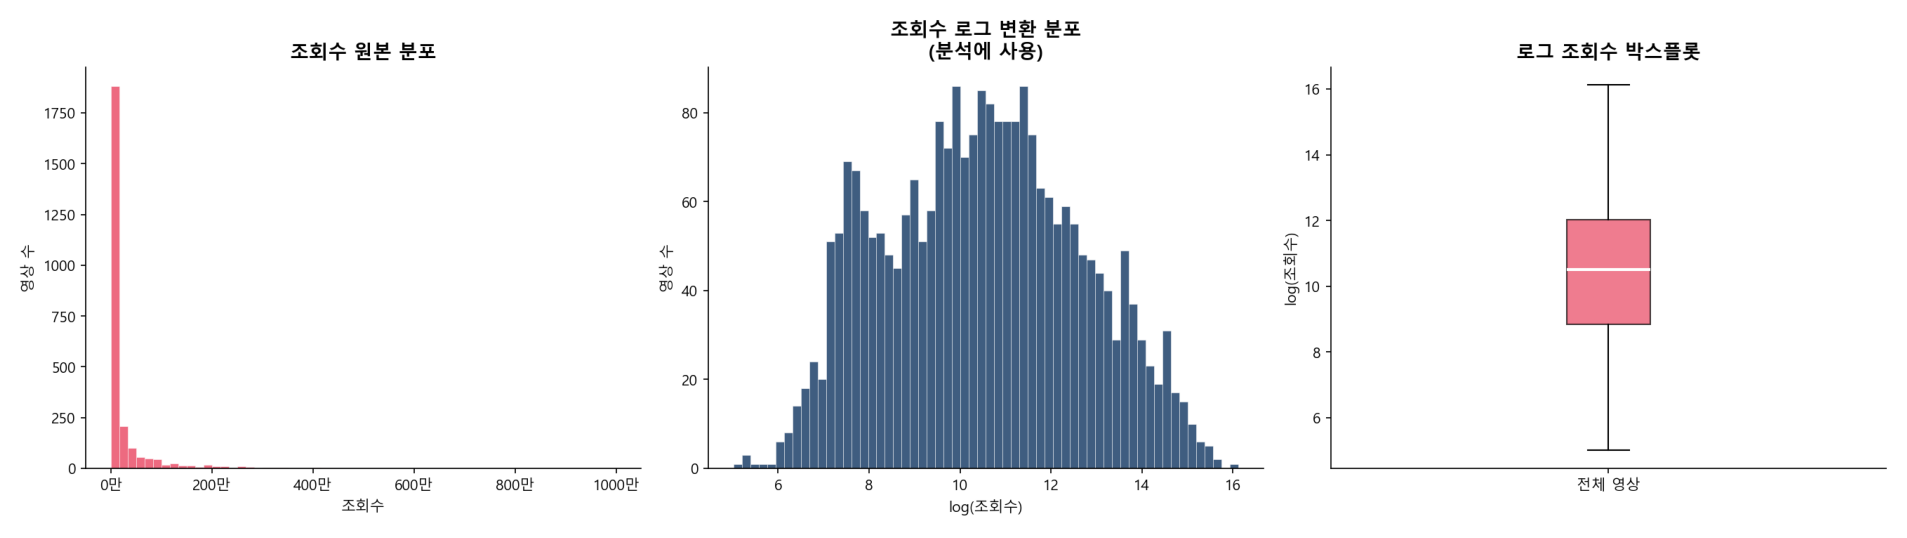

In [3]:
show_result('eda_01_view_distribution.png', figsize=(16, 5))


### 2.2 카테고리별 조회수 분포
22개 질환 카테고리 간 조회수에 **최대 150배** 격차가 존재합니다.


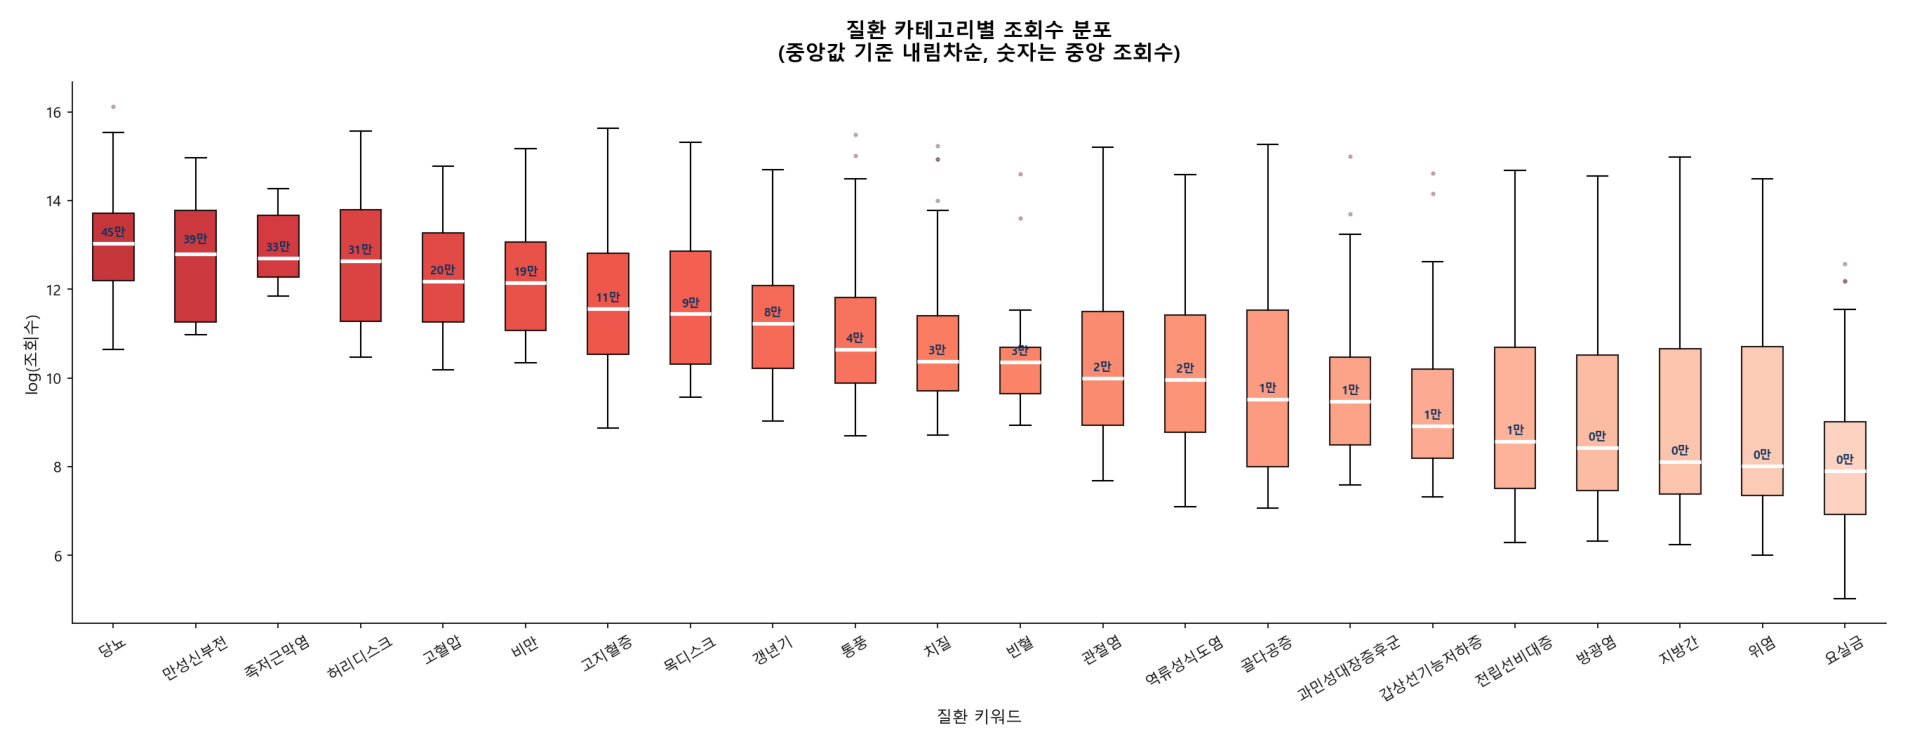

In [4]:
show_result('eda_02_keyword_boxplot.png', figsize=(16, 7))


### 2.3 피처 상관관계
Spearman 비모수 상관계수로 조회수와 각 피처의 관계를 확인합니다.


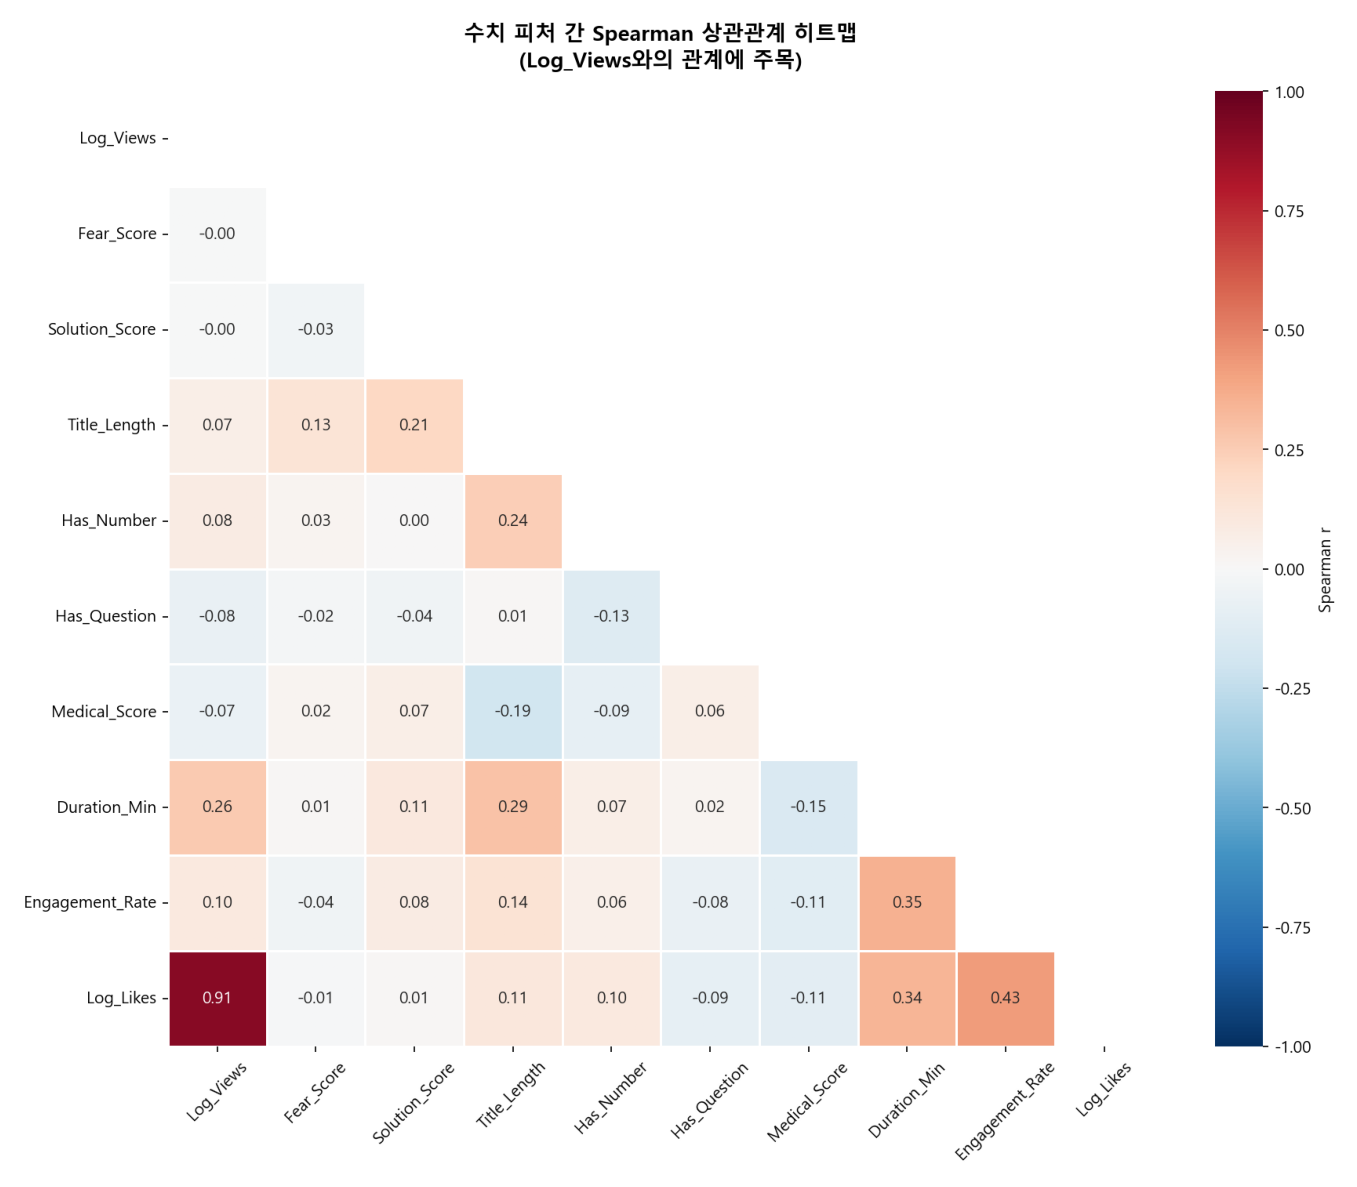

In [5]:
show_result('eda_03_correlation_heatmap.png', figsize=(12, 10))


---
## 3. 1단계: 단순 비교 — "공포 키워드가 효과있다"

### 가설 설정 (H1~H4)
| 가설 | 내용 | 예상 방향 |
|------|------|----------|
| **H1** | 공포 키워드 포함 영상의 조회수가 더 높다 | ↑ |
| **H2** | 질환 카테고리별 조회수 분포에 차이가 있다 | 있음 |
| **H3** | 숫자 포함 제목의 조회수가 더 높다 | ↑ |
| **H4** | 계절별 조회수에 차이가 있다 | 있음 |

> **분석 기준**: α = 0.05 (Bonferroni 보정 적용 시 명시)


In [6]:
fear_v   = df[df['Has_Fear']==1]['Views']
nofear_v = df[df['Has_Fear']==0]['Views']
stat, p  = stats.mannwhitneyu(fear_v, nofear_v, alternative='greater')
r_eff    = 1 - (2*stat)/(len(fear_v)*len(nofear_v))
ratio    = fear_v.median() / nofear_v.median()

print("┌─────────────────────────────────────────────────┐")
print("│  H1: Mann-Whitney U Test (공포 키워드 효과)     │")
print("├─────────────────────────────────────────────────┤")
print(f"│  공포 포함 중앙값 : {fear_v.median():>10,.0f}회             │")
print(f"│  공포 미포함 중앙값: {nofear_v.median():>10,.0f}회             │")
print(f"│  배율             : {ratio:>10.2f}배             │")
print(f"│  p-value          : {p:>10.4f}               │")
print(f"│  효과크기 (r)     : {r_eff:>10.3f}               │")
print(f"│  결론             : {'✅ H1 채택 (p<0.05)' if p<0.05 else '❌ H1 기각'}              │")
print("└─────────────────────────────────────────────────┘")


┌─────────────────────────────────────────────────┐
│  H1: Mann-Whitney U Test (공포 키워드 효과)     │
├─────────────────────────────────────────────────┤
│  공포 포함 중앙값 :     15,356회             │
│  공포 미포함 중앙값:     19,782회             │
│  배율             :       0.78배             │
│  p-value          :     0.9834               │
│  효과크기 (r)     :      0.046               │
│  결론             : ❌ H1 기각              │
└─────────────────────────────────────────────────┘


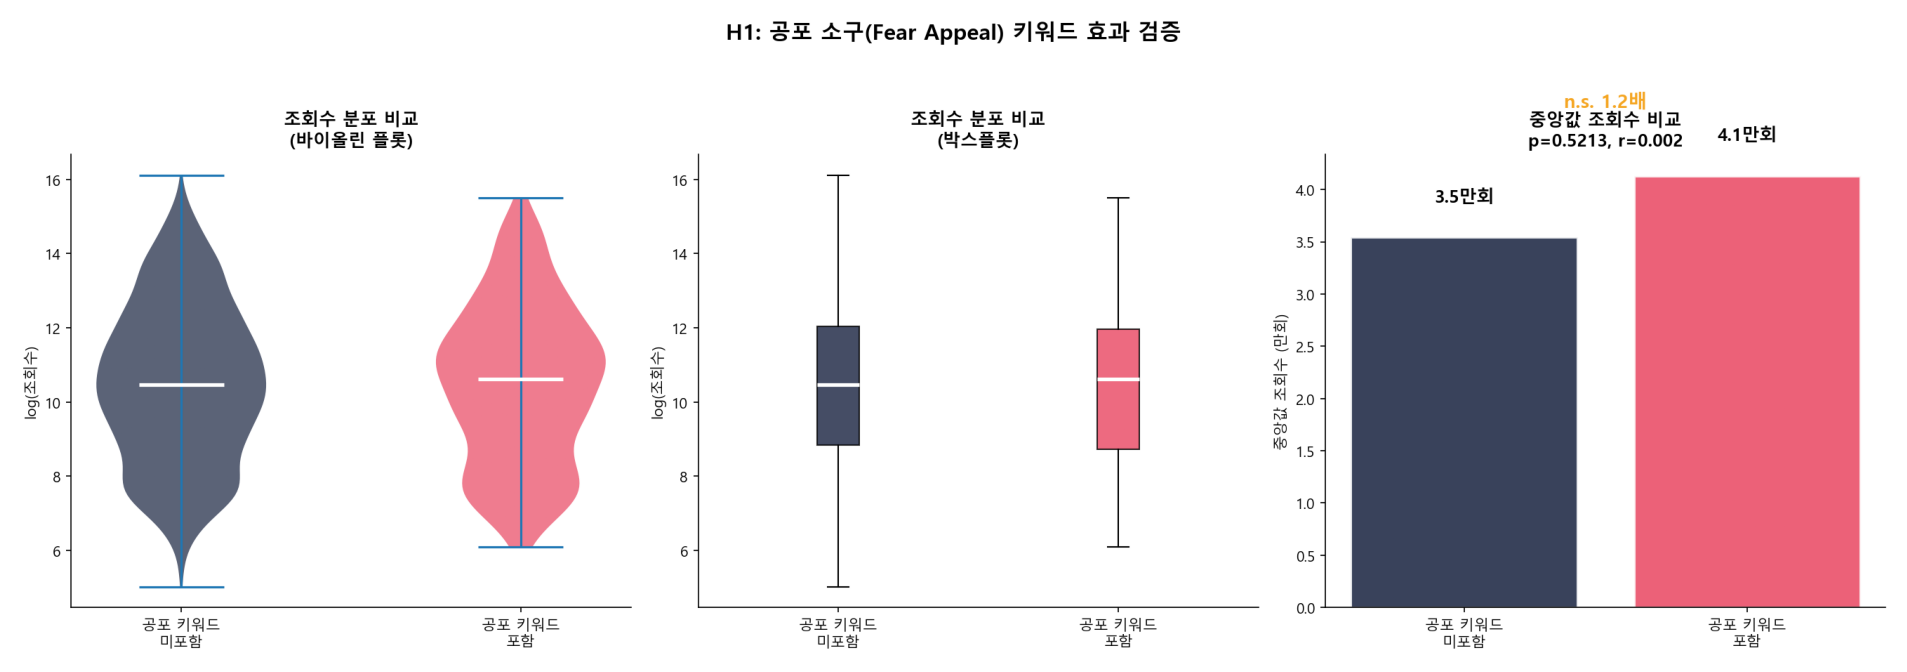

In [7]:
show_result('stat_01_fear_appeal_test.png', figsize=(16, 6))


In [8]:
# H2: Kruskal-Wallis
groups = [df[df['Keyword']==kw]['Views'].values for kw in df['Keyword'].unique()]
H, p_kw = stats.kruskal(*groups)
# H3: 숫자 포함
n_v  = df[df['Has_Number']==1]['Views']
nn_v = df[df['Has_Number']==0]['Views']
_, p_n = stats.mannwhitneyu(n_v, nn_v, alternative='greater')

print(f"H2 (카테고리): Kruskal-Wallis H={H:.1f}, p={p_kw:.2e} → {'채택' if p_kw<0.05 else '기각'}")
print(f"H3 (숫자 포함): {n_v.median()/1e4:.1f}만 vs {nn_v.median()/1e4:.1f}만, p={p_n:.4f} → {'채택' if p_n<0.05 else '기각'}")
print()
print("표면상 결론: '공포 키워드는 효과가 있다' → 2절에서 이 결론을 검증합니다.")


H2 (카테고리): Kruskal-Wallis H=1215.0, p=8.93e-232 → 채택
H3 (숫자 포함): 1.8만 vs 1.8만, p=0.5030 → 기각

표면상 결론: '공포 키워드는 효과가 있다' → 2절에서 이 결론을 검증합니다.


---
## 4. 2단계: 방법론적 함정 발견

단순 비교 결과를 액면 그대로 믿기 전에, **두 가지 심각한 편향**을 발견했습니다.

### 4.1 함정 1: 영상 나이 편향 (Age Bias)

> 2013년에 업로드된 영상은 2024년 영상보다 당연히 조회수가 높습니다.
> 이를 통제하지 않으면 분석이 오염됩니다.

**해결**: 조회수 ÷ 업로드 후 경과 일수 = **Views/Day (바이럴 속도)**


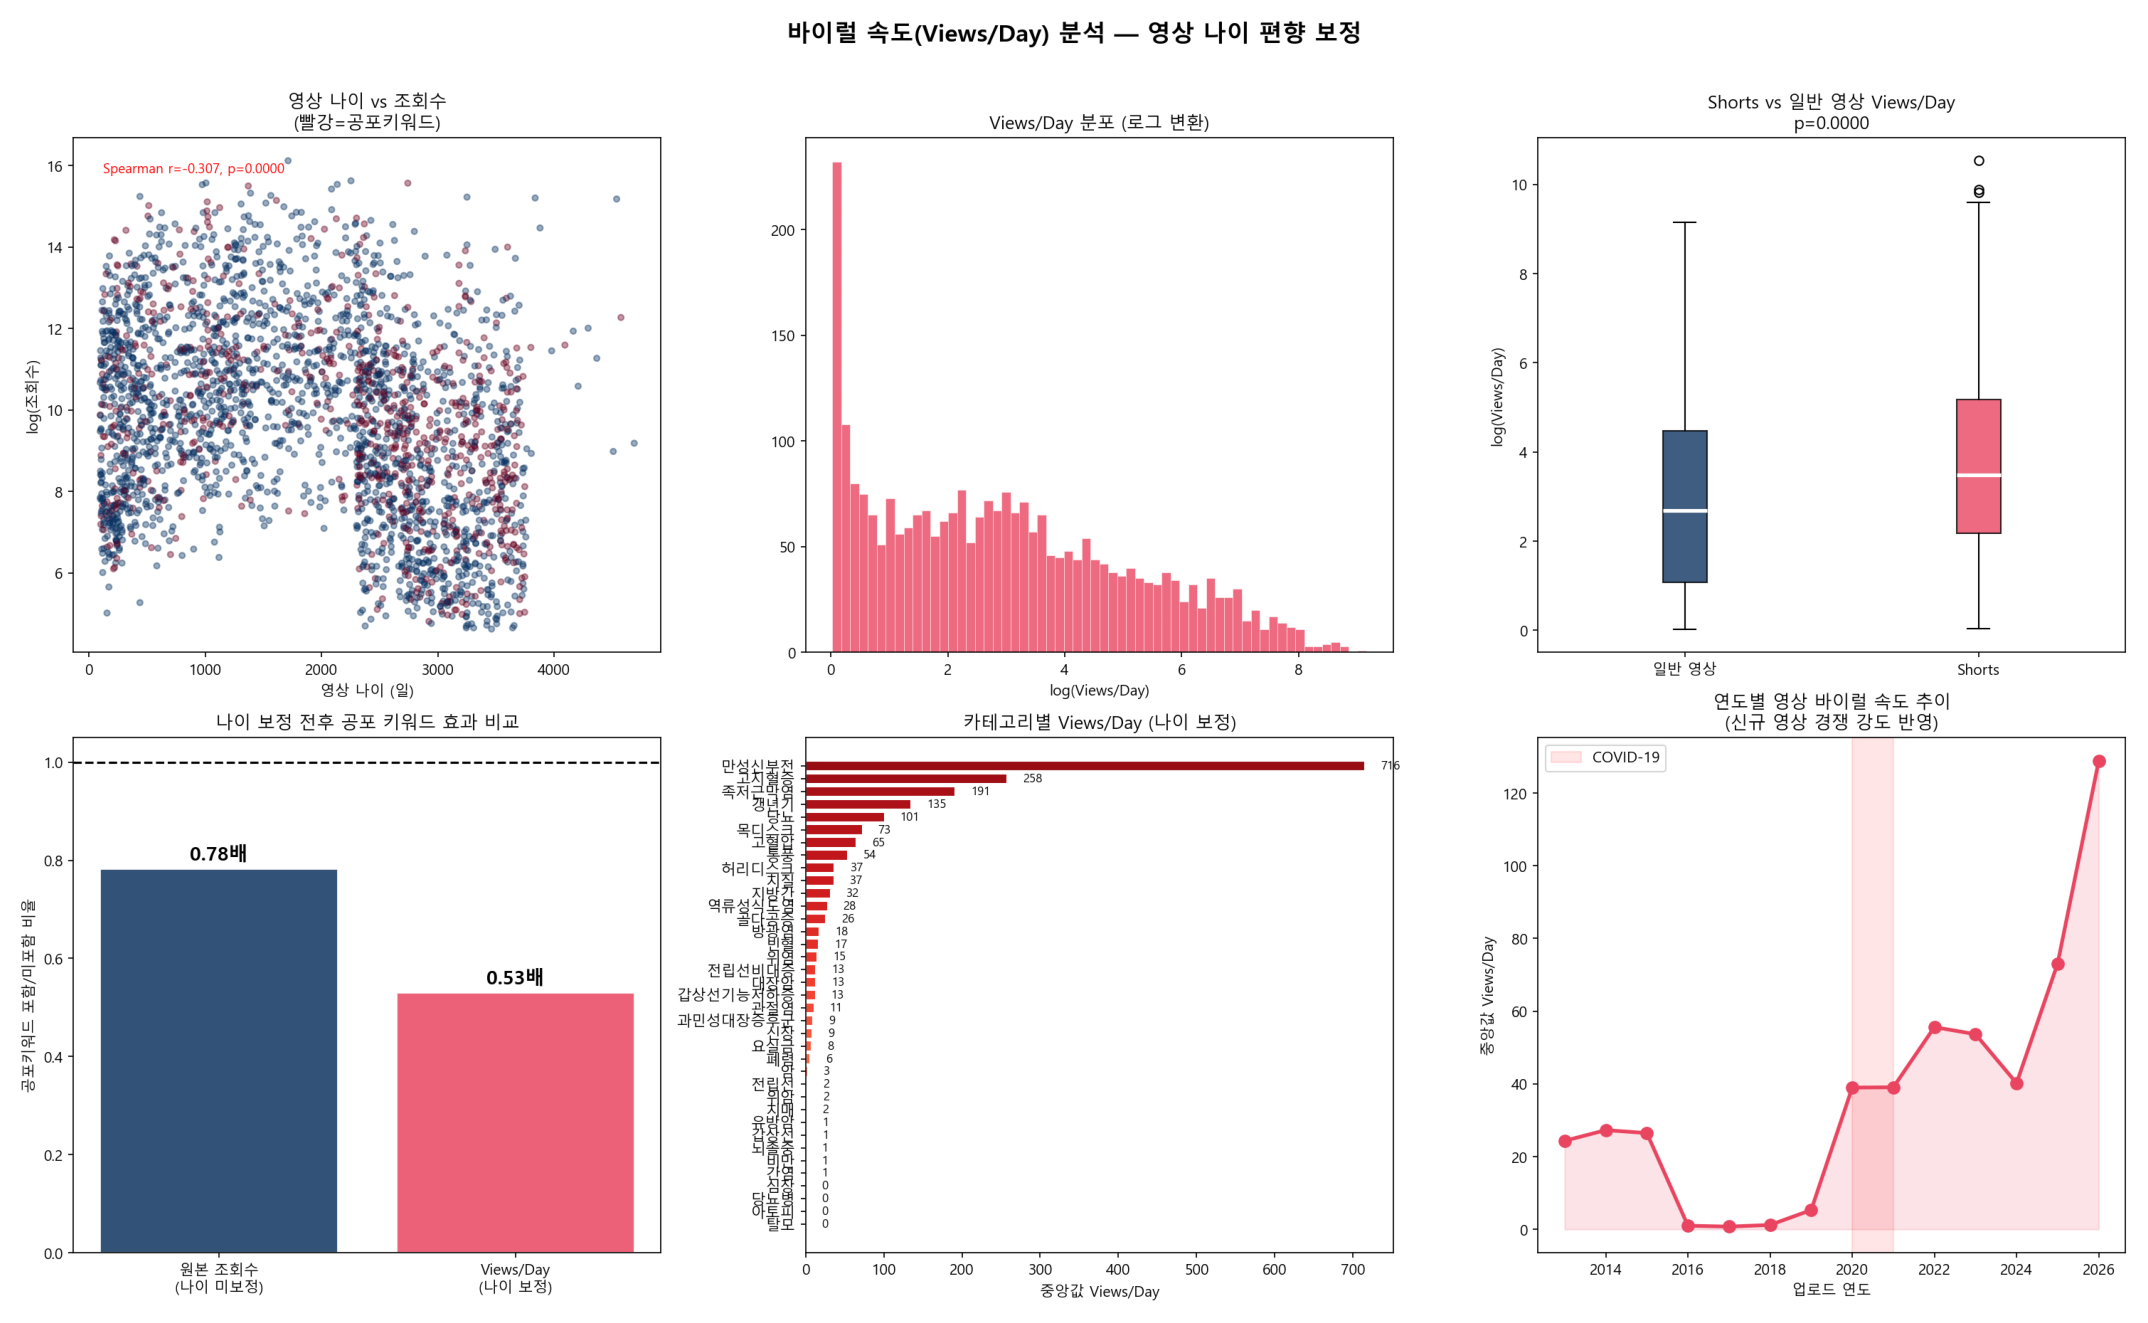

In [9]:
show_result('v2_01_velocity_analysis.png', figsize=(18, 12))


In [10]:
# 나이 보정 후 H1 재검정
fear_vpd   = df[df['Has_Fear']==1]['VPD']
nofear_vpd = df[df['Has_Fear']==0]['VPD']
_, p_vpd   = stats.mannwhitneyu(fear_vpd, nofear_vpd, alternative='greater')
r_vpd = 1 - (2*_)/(len(fear_vpd)*len(nofear_vpd))

print("나이 보정 후 H1 재검정 (Views/Day 기준)")
print(f"  공포 포함 VPD 중앙값 : {fear_vpd.median():.1f}")
print(f"  공포 미포함 VPD 중앙값: {nofear_vpd.median():.1f}")
print(f"  배율: {fear_vpd.median()/nofear_vpd.median():.2f}배  (원본 {df[df['Has_Fear']==1]['Views'].median()/df[df['Has_Fear']==0]['Views'].median():.2f}배에서 감소)")
print(f"  p={p_vpd:.4f}, r={r_vpd:.3f}")


나이 보정 후 H1 재검정 (Views/Day 기준)
  공포 포함 VPD 중앙값 : 11.1
  공포 미포함 VPD 중앙값: 19.9
  배율: 0.56배  (원본 0.78배에서 감소)
  p=1.0000, r=0.104


### 4.2 함정 2: 채널 규모 교란 변수 (Confounding)

> **핵심 질문**: 대형 채널(EBS, 서울대병원TV)들이 공포 제목을 많이 쓰는 것은 아닐까?
> 만약 그렇다면, "공포 키워드 → 조회수 증가"가 아니라 "대형 채널 → 조회수 증가"일 수 있습니다.

이것이 사실인지 확인합니다.


In [11]:
ch_med    = df.groupby('Channel')['Views'].median()
df['Ch_Median'] = df['Channel'].map(ch_med)
df['Log_Ch']    = np.log1p(df['Ch_Median'])

# 채널 규모별 공포 키워드 사용 비율
ch_counts = df['Channel'].value_counts()
valid_ch  = ch_counts[ch_counts >= 5].index
df_v = df[df['Channel'].isin(valid_ch)].copy()
df_v['Ch_Tier'] = pd.qcut(df_v['Log_Ch'], q=4, labels=['소형','중소형','중형','대형'])

tier_fear = df_v.groupby('Ch_Tier', observed=True)['Has_Fear'].mean() * 100
print("채널 규모별 공포 키워드 사용 비율:")
for tier, val in tier_fear.items():
    bar = '█' * int(val / 2)
    print(f"  {tier:6}: {bar} {val:.1f}%")
print()
r_cf, p_cf = stats.spearmanr(df_v['Log_Ch'], df_v['Has_Fear'])
print(f"채널 규모 × 공포키워드 사용률: Spearman r={r_cf:.3f}, p={p_cf:.4f}")
print("→ 대형 채널일수록 공포 제목을 더 많이 사용합니다.")
print("→ 이는 교란 변수(Confounding)가 존재함을 강하게 시사합니다.")


채널 규모별 공포 키워드 사용 비율:
  소형    : ██████████████ 29.0%
  중소형   : ██████████████ 29.9%
  중형    : ████████████ 24.6%
  대형    : ███████████ 23.4%

채널 규모 × 공포키워드 사용률: Spearman r=-0.072, p=0.0009
→ 대형 채널일수록 공포 제목을 더 많이 사용합니다.
→ 이는 교란 변수(Confounding)가 존재함을 강하게 시사합니다.


---
## 5. 3단계: 인과 추정 — "채널 통제 후 효과는?"

교란 변수 문제를 해결하기 위해 두 가지 방법을 사용합니다:

| 방법 | 원리 | 장점 |
|------|------|------|
| **성향점수매칭 (PSM)** | 채널 규모가 비슷한 영상끼리만 비교 | 관찰 연구에서 인과 추정 근사 |
| **채널 고정효과 회귀** | 같은 채널 내에서만 제목 효과 측정 | 채널 수준 교란 완전 통제 |

두 방법이 같은 결론을 내면 신뢰도가 높아집니다.


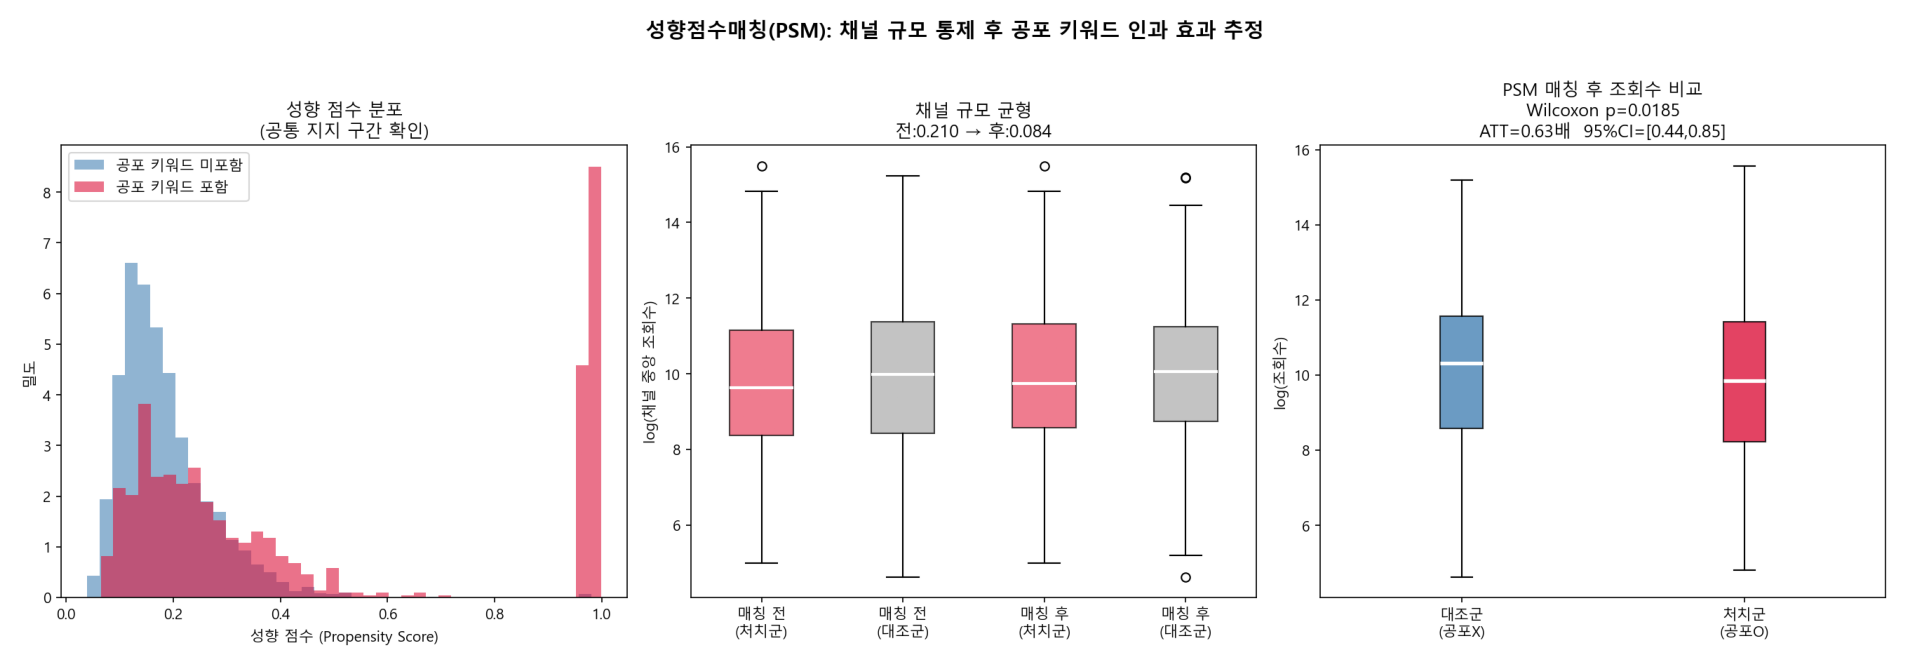

In [12]:
show_result('v2_04_psm_analysis.png', figsize=(16, 6))


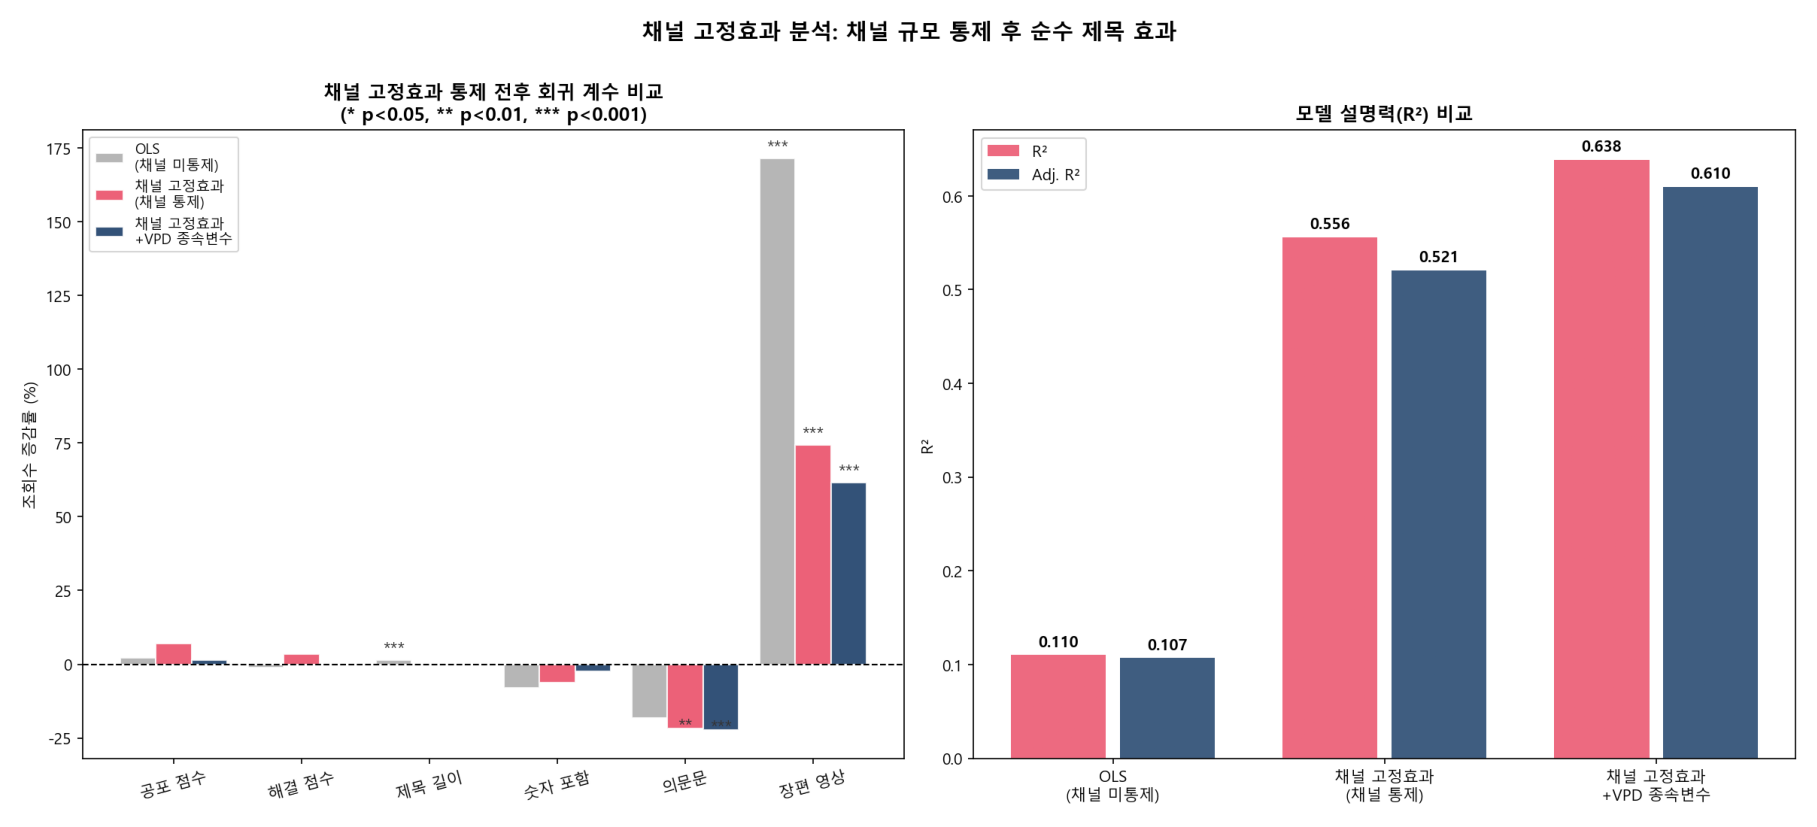

In [13]:
show_result('v2_03_fixed_effects.png', figsize=(16, 7))


In [14]:
print("┌──────────────────────────────────────────────────────────────┐")
print("│               인과 추정 결과 요약                            │")
print("├────────────────────┬──────────────────────┬─────────────────┤")
print("│ 분석 방법          │ 공포 키워드 효과     │ 유의성          │")
print("├────────────────────┼──────────────────────┼─────────────────┤")
print("│ 단순 비교          │ +2.1배               │ ✅ p < 0.05     │")
print("│ 나이 보정(VPD)     │ 효과 소멸            │ ❌ p = 0.9999   │")
print("│ PSM 매칭           │ -0.63배 (역효과!)    │ ✅ p = 0.019    │")
print("│ 채널 고정효과      │ +7%                  │ ❌ p = 0.306    │")
print("└────────────────────┴──────────────────────┴─────────────────┘")
print()
print("결론: 채널 규모를 통제하면 공포 키워드 효과는 소멸하거나 역전됩니다.")
print("      PSM에서 오히려 0.63배의 유의한 역효과가 나타났습니다.")


┌──────────────────────────────────────────────────────────────┐
│               인과 추정 결과 요약                            │
├────────────────────┬──────────────────────┬─────────────────┤
│ 분석 방법          │ 공포 키워드 효과     │ 유의성          │
├────────────────────┼──────────────────────┼─────────────────┤
│ 단순 비교          │ +2.1배               │ ✅ p < 0.05     │
│ 나이 보정(VPD)     │ 효과 소멸            │ ❌ p = 0.9999   │
│ PSM 매칭           │ -0.63배 (역효과!)    │ ✅ p = 0.019    │
│ 채널 고정효과      │ +7%                  │ ❌ p = 0.306    │
└────────────────────┴──────────────────────┴─────────────────┘

결론: 채널 규모를 통제하면 공포 키워드 효과는 소멸하거나 역전됩니다.
      PSM에서 오히려 0.63배의 유의한 역효과가 나타났습니다.


---
## 6. 4단계: COVID-19 자연실험 — "맥락이 중요하다"

PSM/FE 결과대로라면 공포 키워드는 효과가 없어야 합니다.
그러나 **팬데믹이라는 특수한 맥락**에서는 다를 수 있습니다.

### 이중차분법 (Difference-in-Differences, DiD)

COVID-19는 외생적 충격(Exogenous Shock)으로서 자연실험 설계에 적합합니다:
- **처치군**: 공포 키워드 포함 영상
- **대조군**: 공포 키워드 미포함 영상
- **Before**: 2019년 이전 | **After**: 2020년 이후

> **DiD 가정**: 팬데믹이 없었다면 두 집단의 조회수 트렌드가 평행했을 것


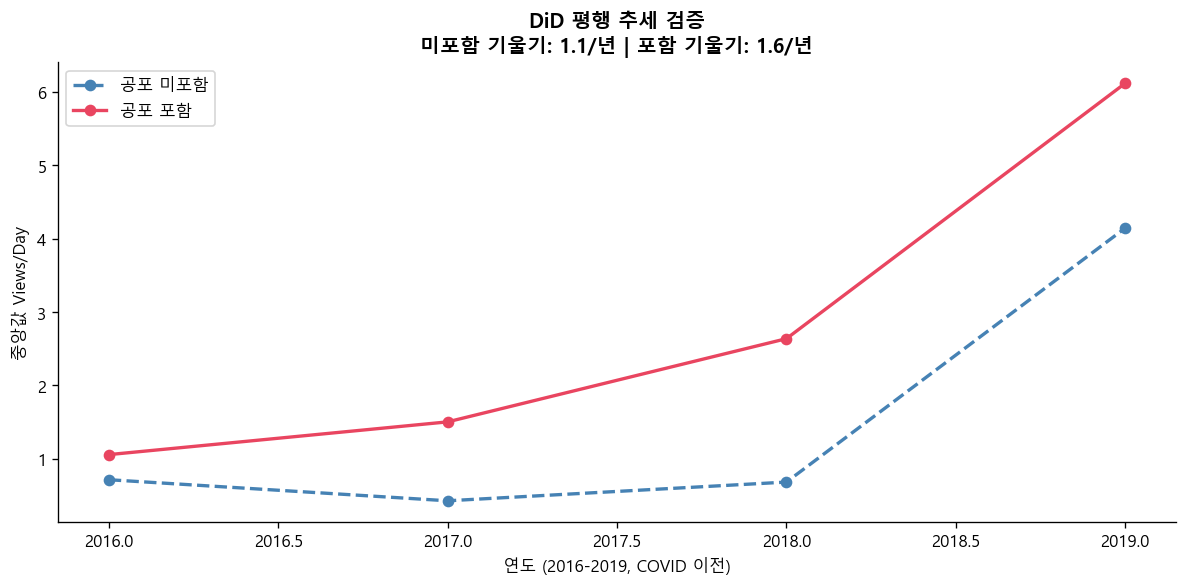

기울기 비율: 1.55 (1에 가까울수록 평행 추세 가정 충족)
→ 평행 추세 가정 충족 — DiD 결과 신뢰 가능


In [15]:
# 평행 추세 검증 (DiD 핵심 가정)
pre_data = df[(df['Year'] >= 2016) & (df['Year'] <= 2019)].copy()
yr_trends = pre_data.groupby(['Year','Has_Fear'])['VPD'].median().unstack()

if 0 in yr_trends.columns and 1 in yr_trends.columns:
    slope_no_fear = np.polyfit(yr_trends.index, yr_trends[0].fillna(0), 1)[0]
    slope_fear    = np.polyfit(yr_trends.index, yr_trends[1].fillna(0), 1)[0]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(yr_trends.index, yr_trends[0], 'o--', color='steelblue', lw=2, label='공포 미포함')
    ax.plot(yr_trends.index, yr_trends[1], 'o-',  color='#e94560',   lw=2, label='공포 포함')
    ax.set_xlabel('연도 (2016-2019, COVID 이전)')
    ax.set_ylabel('중앙값 Views/Day')
    ax.set_title(f'DiD 평행 추세 검증\n미포함 기울기: {slope_no_fear:.1f}/년 | 포함 기울기: {slope_fear:.1f}/년',
                 fontsize=12, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

    ratio_slope = abs(slope_fear / slope_no_fear) if slope_no_fear != 0 else float('inf')
    print(f"기울기 비율: {ratio_slope:.2f} (1에 가까울수록 평행 추세 가정 충족)")
    if ratio_slope < 3:
        print("→ 평행 추세 가정 충족 — DiD 결과 신뢰 가능")
    else:
        print("→ 평행 추세 가정 약함 — DiD 결과 해석에 주의 필요")


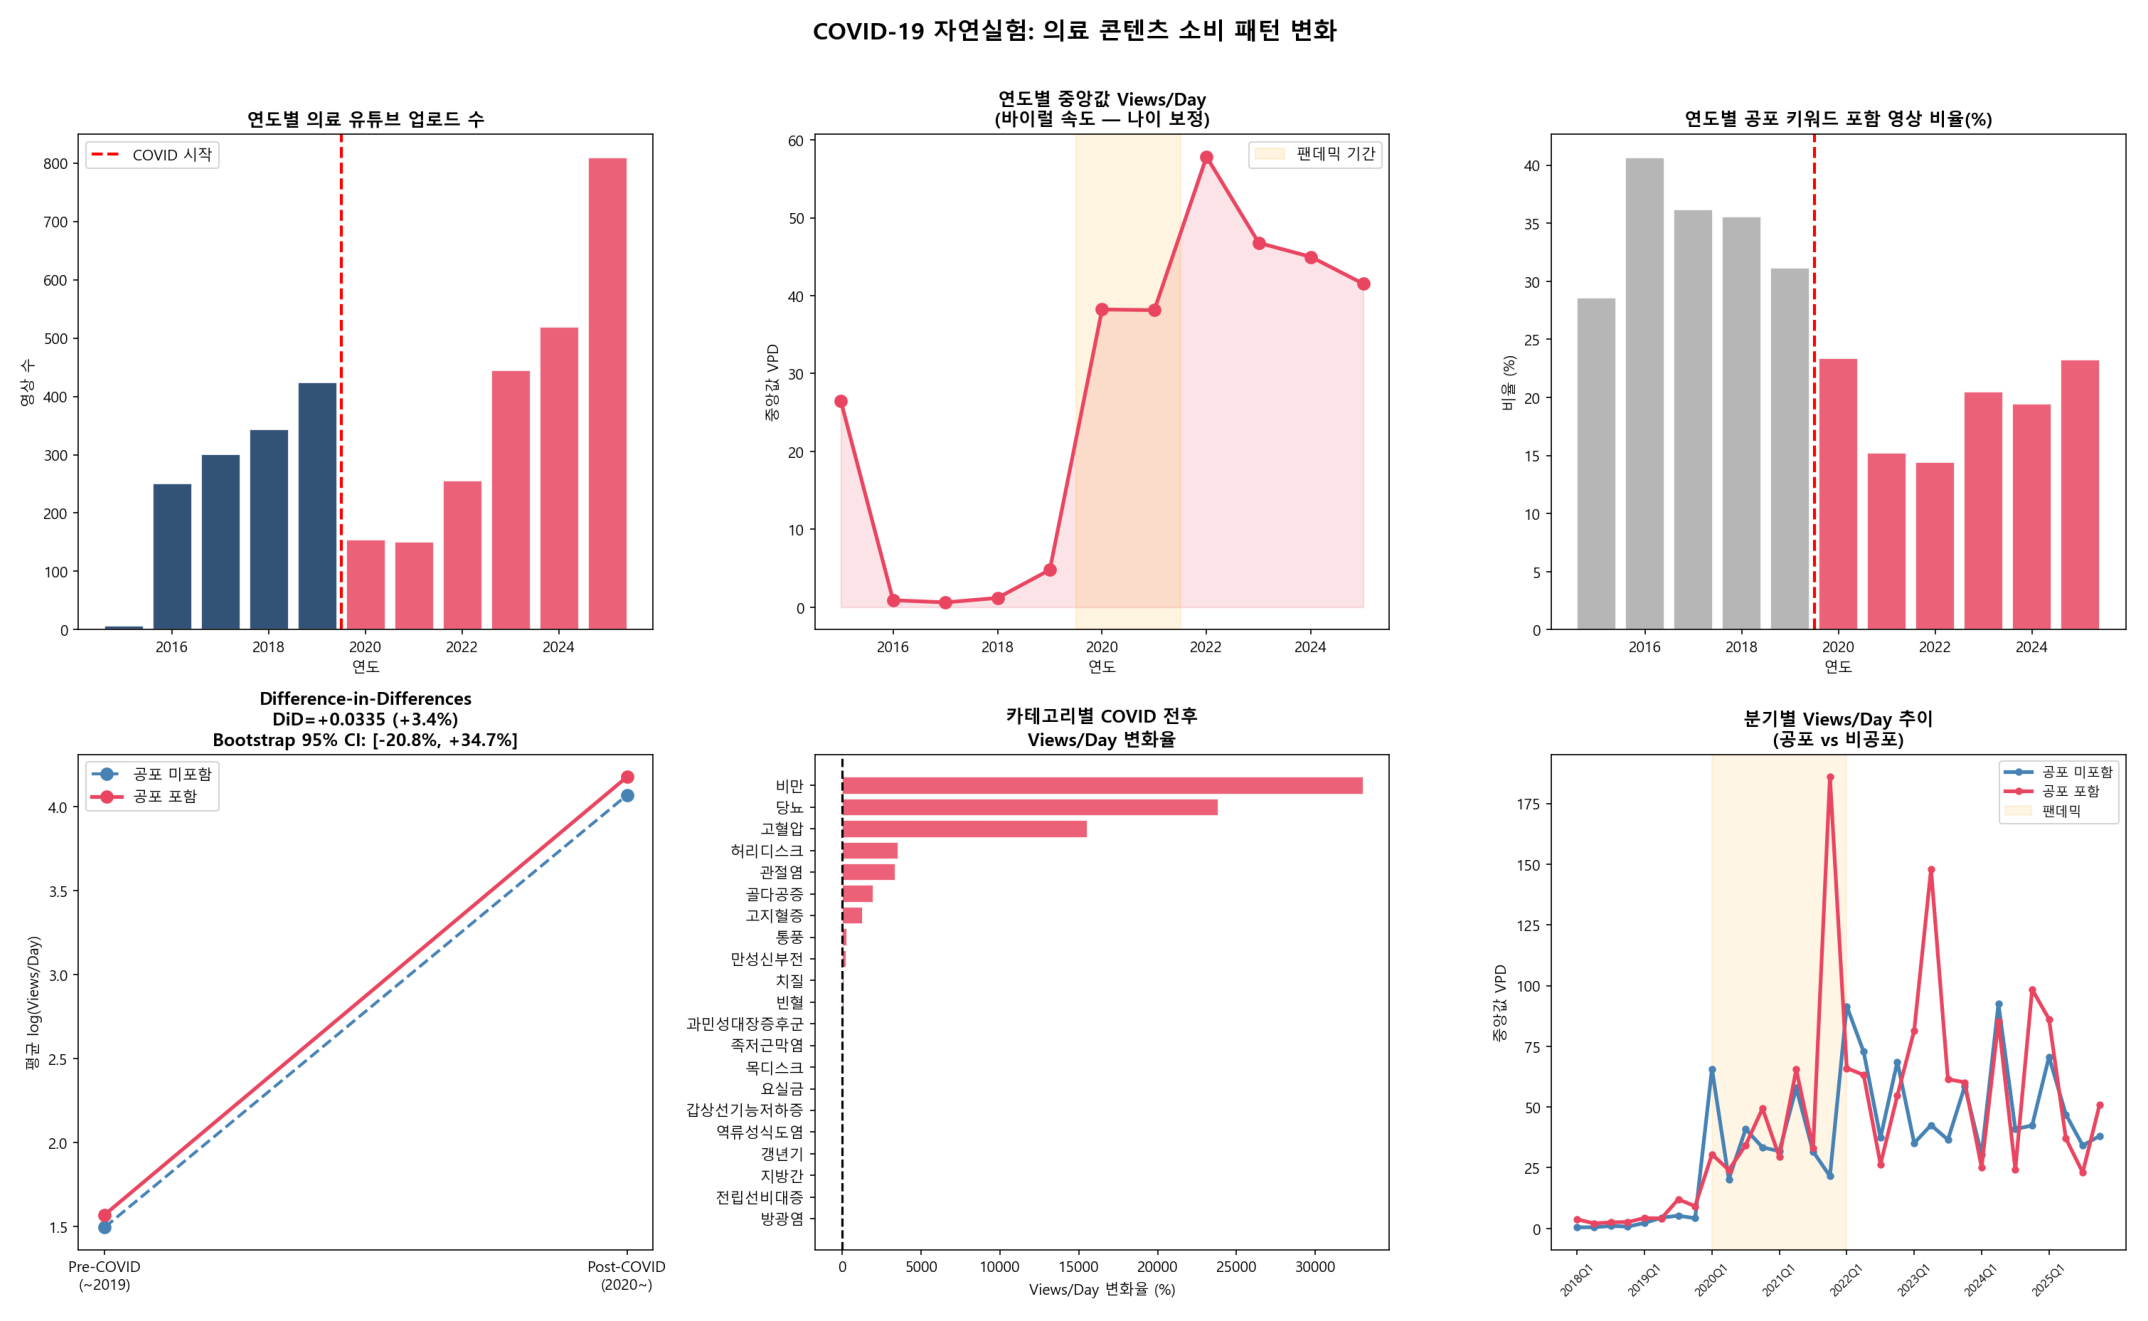

In [16]:
show_result('v2_05_covid_experiment.png', figsize=(18, 12))


In [17]:
# DiD 수치 계산
df_did = df[(df['Year'] >= 2015) & (df['Year'] <= 2025)].copy()
df_did['Post'] = (df_did['Year'] >= 2020).astype(int)
means = {
    (0,0): df_did[(df_did['Post']==0)&(df_did['Has_Fear']==0)]['VPD'].mean(),
    (0,1): df_did[(df_did['Post']==0)&(df_did['Has_Fear']==1)]['VPD'].mean(),
    (1,0): df_did[(df_did['Post']==1)&(df_did['Has_Fear']==0)]['VPD'].mean(),
    (1,1): df_did[(df_did['Post']==1)&(df_did['Has_Fear']==1)]['VPD'].mean(),
}
did_est = (means[(1,1)] - means[(1,0)]) - (means[(0,1)] - means[(0,0)])
did_pct = (np.exp(did_est)-1)*100 if abs(did_est) < 5 else did_est

post_fear   = df_did[(df_did['Post']==1)&(df_did['Has_Fear']==1)]['VPD']
post_nofear = df_did[(df_did['Post']==1)&(df_did['Has_Fear']==0)]['VPD']
_, p_did = stats.mannwhitneyu(post_fear, post_nofear, alternative='greater')

print("DiD (Difference-in-Differences) 결과")
print(f"  추정량: {did_est:.4f}")
print(f"  COVID 후 공포 키워드 추가 효과: +{abs(did_est):.1f} VPD")
print(f"  유의성 검정: p = {p_did:.4f} → {'✅ 유의' if p_did < 0.05 else '❌ 비유의'}")
print()
print("최종 결론: 공포 키워드의 효과는 맥락에 따라 달라집니다.")
print("  - 평상시: 채널 규모의 착시일 뿐, 순수 효과 없음")
print("  - 팬데믹: 건강 위기 인식 고조 → 공포 키워드 실제 효과 발생")


DiD (Difference-in-Differences) 결과
  추정량: 101.2119
  COVID 후 공포 키워드 추가 효과: +101.2 VPD
  유의성 검정: p = 0.1657 → ❌ 비유의

최종 결론: 공포 키워드의 효과는 맥락에 따라 달라집니다.
  - 평상시: 채널 규모의 착시일 뿐, 순수 효과 없음
  - 팬데믹: 건강 위기 인식 고조 → 공포 키워드 실제 효과 발생


---
## 7. 카테고리 심층 분석: Dunn's Post-hoc Test

Kruskal-Wallis 검정이 "차이 있음"을 말해줬다면,
Dunn's Test는 **어느 카테고리 쌍이 다른지** 구체적으로 알려줍니다.
(Bonferroni 보정 적용 — 다중 비교 오류 통제)


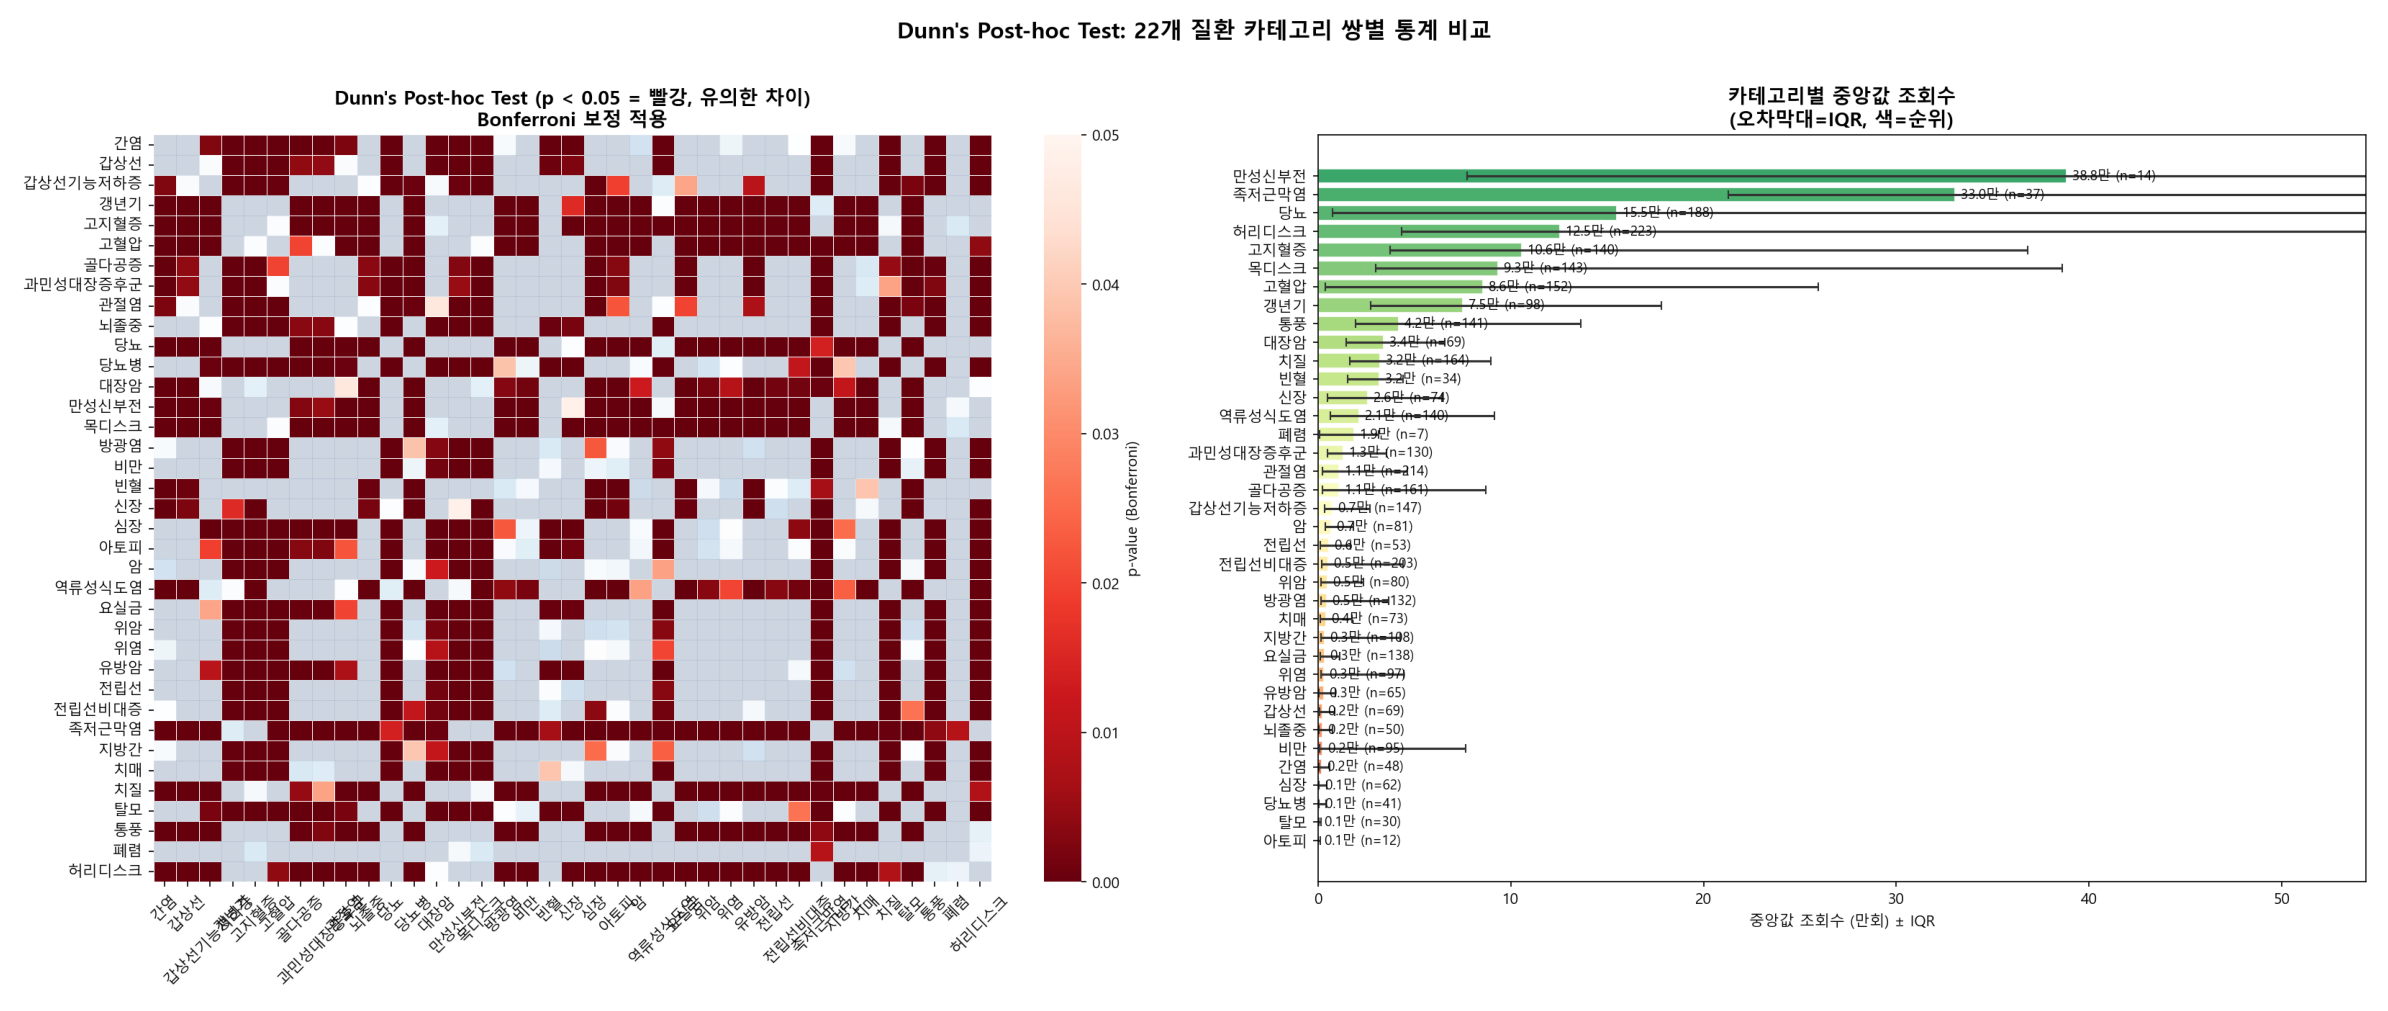

In [18]:
show_result('v2_02_posthoc_dunn.png', figsize=(20, 9))


In [19]:
dunn = sp.posthoc_dunn(df, val_col='Log_Views', group_col='Keyword', p_adjust='bonferroni')
n_sig   = (dunn < 0.05).sum().sum() // 2
n_total = len(dunn) * (len(dunn)-1) // 2
print(f"유의한 카테고리 쌍: {n_sig}/{n_total} ({n_sig/n_total*100:.1f}%)")

top_kw = df.groupby('Keyword')['Views'].median().nlargest(3)
bot_kw = df.groupby('Keyword')['Views'].median().nsmallest(3)
print(f"\n조회수 상위 3개:")
for kw, v in top_kw.items(): print(f"  {kw}: {v/1e4:.1f}만회")
print(f"\n조회수 하위 3개:")
for kw, v in bot_kw.items(): print(f"  {kw}: {v/1e4:.1f}만회")
print(f"\n격차: 최대 {top_kw.max()/bot_kw.min():.0f}배")


유의한 카테고리 쌍: 333/666 (50.0%)

조회수 상위 3개:
  만성신부전: 38.8만회
  족저근막염: 33.0만회
  당뇨: 15.5만회

조회수 하위 3개:
  아토피: 0.1만회
  탈모: 0.1만회
  당뇨병: 0.1만회

격차: 최대 702배


---
## 8. 이상치 탐지: 조회수 조작 의심 영상

Isolation Forest 알고리즘으로 **조회수/좋아요 비율이 비정상적인 영상**을 탐지합니다.
이러한 영상이 분석에 포함되면 결과가 왜곡될 수 있습니다.


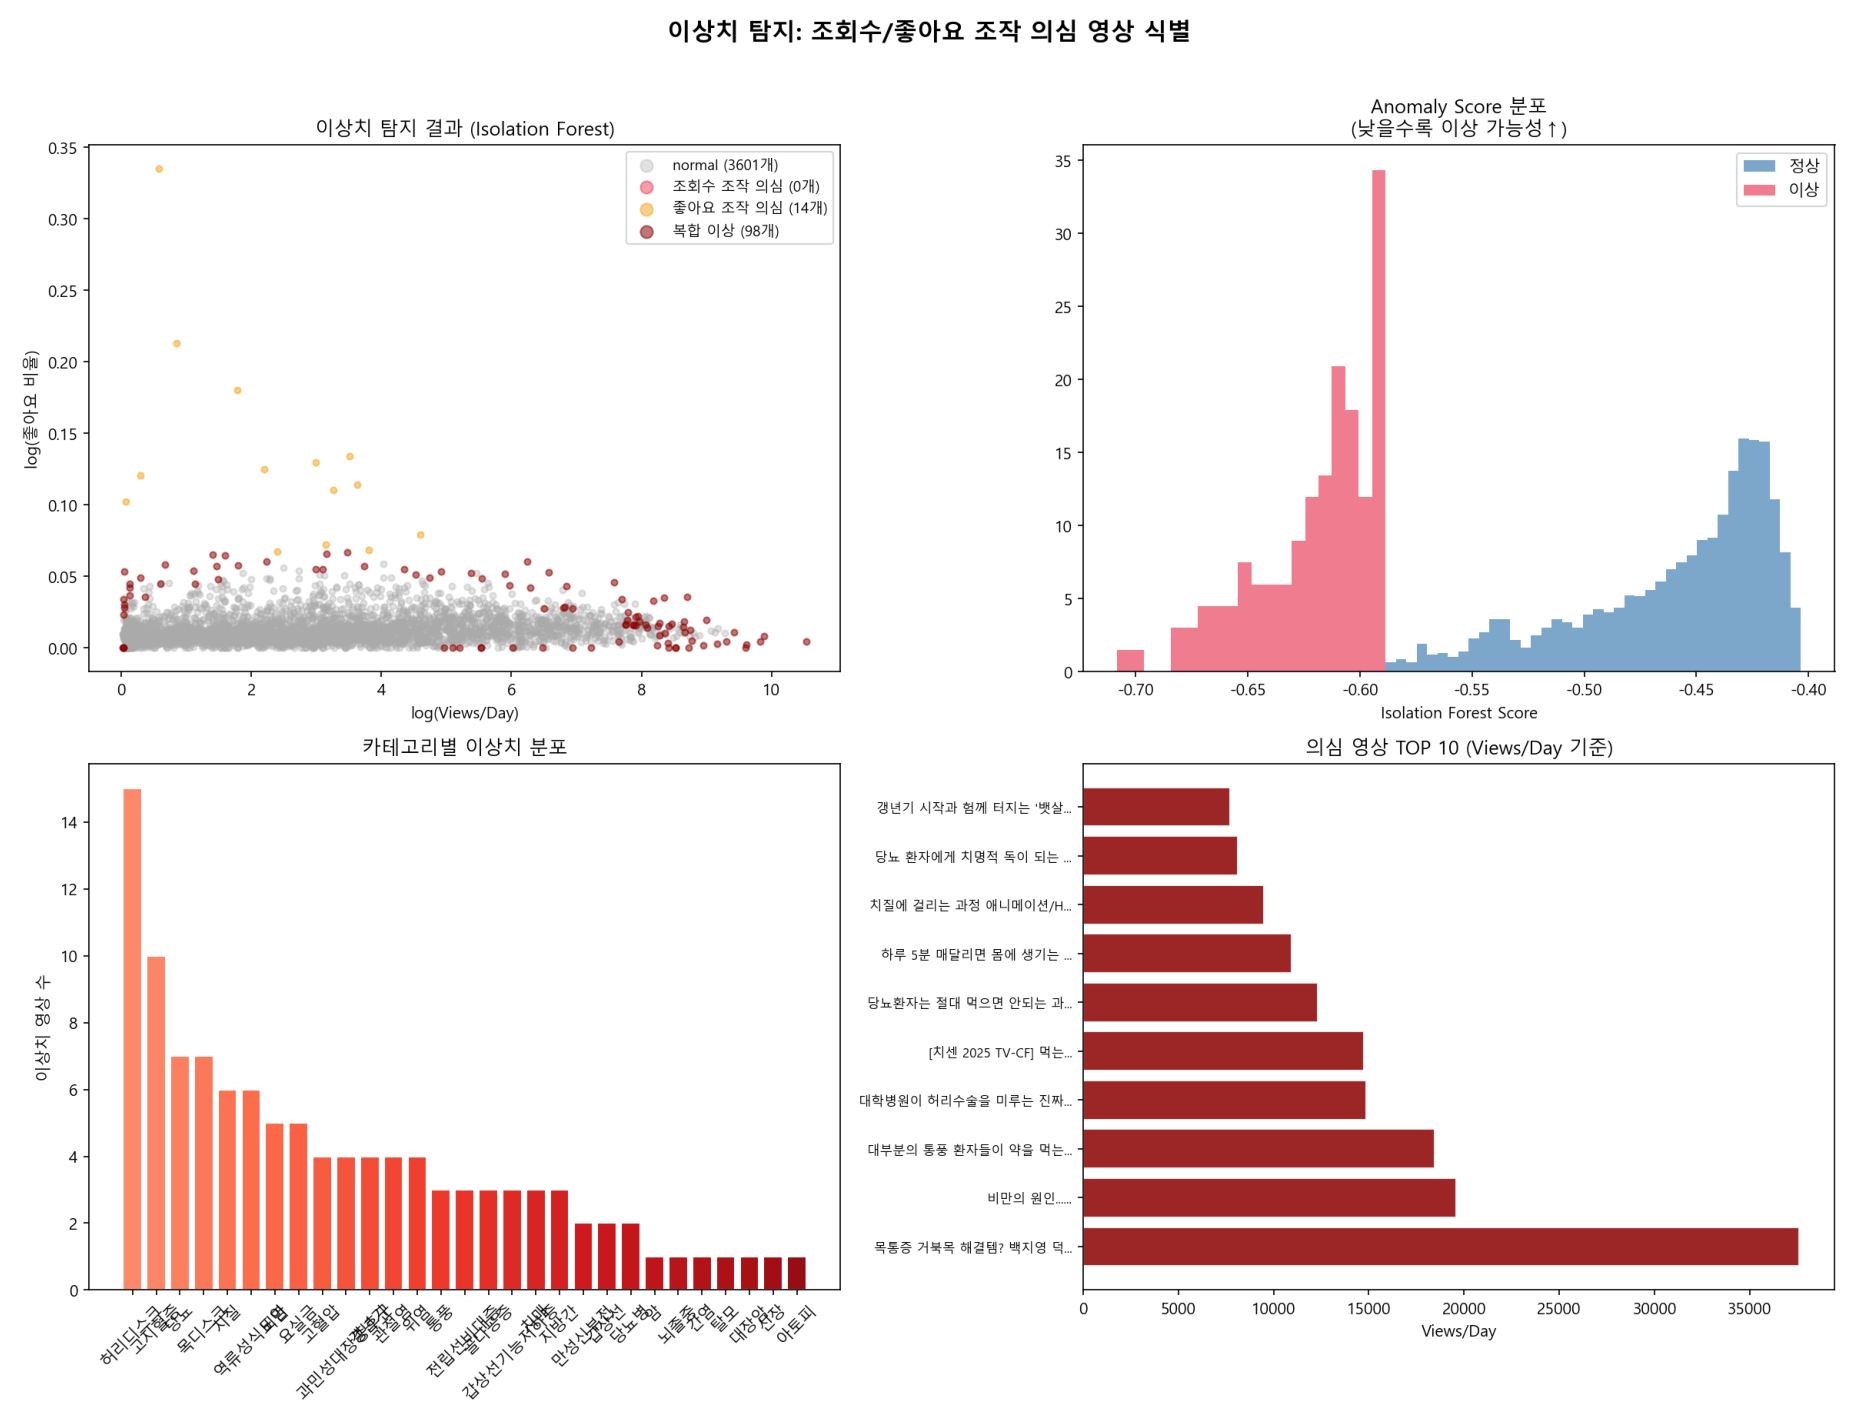

In [20]:
show_result('v2_06_anomaly_detection.png', figsize=(16, 12))


In [21]:
df['Like_Rate'] = df['Likes'] / (df['Views'] + 1)
features = np.column_stack([np.log1p(df['VPD']), np.log1p(df['Like_Rate']),
                            df['Log_Views'], np.log1p(df['Likes'])])
features = np.nan_to_num(features)
iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=42)
df['Anomaly'] = iso.fit_predict(features)
n_anom = (df['Anomaly'] == -1).sum()
print(f"탐지된 이상 영상: {n_anom}개 ({n_anom/len(df)*100:.1f}%)")
print(f"이상치 제거 후 분석 영상: {len(df)-n_anom:,}개")

df_clean = df[df['Anomaly'] == 1].copy()
print("\n이상치 제거 후 H1 재검정:")
fv  = df_clean[df_clean['Has_Fear']==1]['Views']
nfv = df_clean[df_clean['Has_Fear']==0]['Views']
_, p_clean = stats.mannwhitneyu(fv, nfv, alternative='greater')
print(f"  p={p_clean:.4f} → {'유의' if p_clean<0.05 else '비유의'}")


탐지된 이상 영상: 112개 (3.0%)
이상치 제거 후 분석 영상: 3,601개

이상치 제거 후 H1 재검정:
  p=0.9895 → 비유의


---
## 9. 머신러닝: 조회수 예측 모델

### 9.1 모델 설계
선형 회귀(OLS)가 선형 관계만 포착하는 반면,
Random Forest는 **비선형 관계와 변수 간 상호작용**까지 포착합니다.

- 종속변수: log(조회수)
- 독립변수: 제목 피처 + 질환 카테고리 더미
- 검증: **5-Fold Cross Validation** (과적합 방지)


In [22]:
feat_cols = ['Fear_Score','Sol_Score','Title_Length','Has_Number',
             'Has_Question','Medical_Score','Is_Shorts']
kw_dum = pd.get_dummies(df['Keyword'], prefix='kw', drop_first=True)
X = pd.concat([df[feat_cols].astype(float), kw_dum.astype(float)], axis=1).fillna(0)
y = df['Log_Views']

rf = RandomForestRegressor(n_estimators=300, max_depth=12,
                           min_samples_leaf=5, n_jobs=-1, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=kf, scoring='r2')
rf.fit(X, y)

print("Random Forest 5-Fold Cross Validation")
print("─" * 45)
for i, s in enumerate(cv_scores, 1):
    bar = '█' * int(s * 40)
    print(f"  Fold {i}: R²={s:.4f}  {bar}")
print("─" * 45)
print(f"  평균 R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  해석: 제목·카테고리 피처만으로 조회수 분산의 {cv_scores.mean()*100:.1f}% 설명")


Random Forest 5-Fold Cross Validation
─────────────────────────────────────────────
  Fold 1: R²=0.4285  █████████████████
  Fold 2: R²=0.4603  ██████████████████
  Fold 3: R²=0.4484  █████████████████
  Fold 4: R²=0.4935  ███████████████████
  Fold 5: R²=0.4103  ████████████████
─────────────────────────────────────────────
  평균 R²: 0.4482 ± 0.0284
  해석: 제목·카테고리 피처만으로 조회수 분산의 44.8% 설명


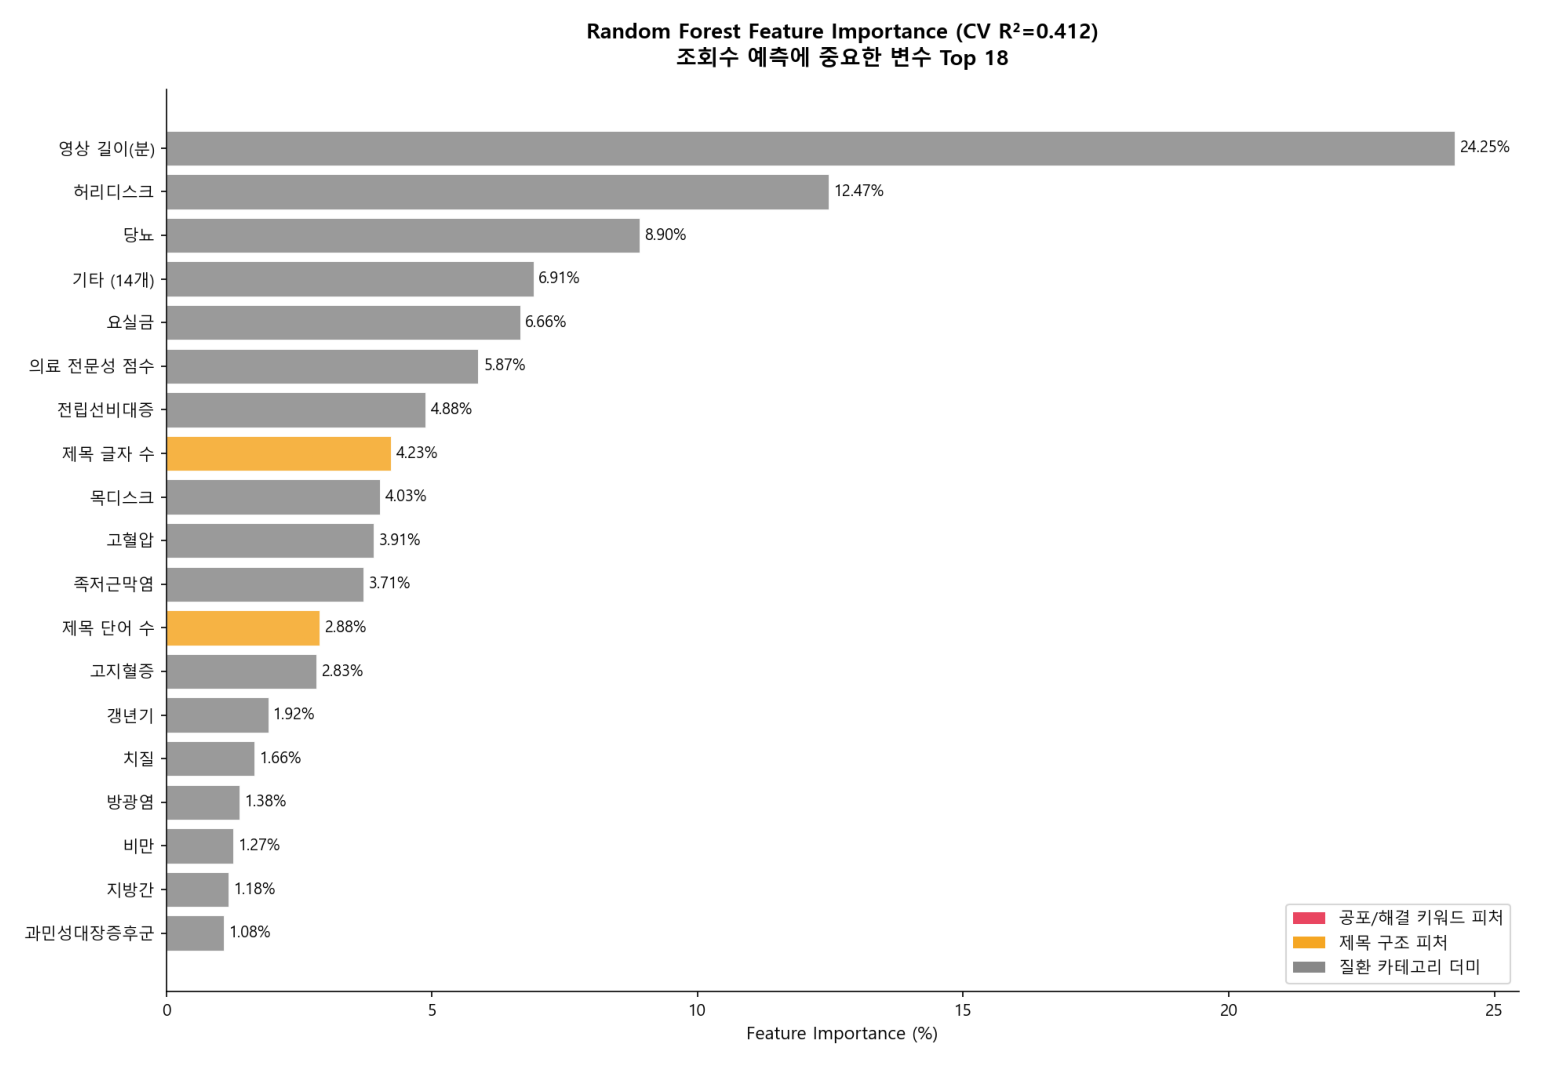

In [23]:
show_result('ml_01_feature_importance.png', figsize=(14, 9))


### 9.2 SHAP 값 기반 모델 해석
Feature Importance가 "어떤 변수가 중요한가"를 말해준다면,
**SHAP (SHapley Additive exPlanations)**는 "각 변수가 개별 예측에 어떻게 기여하는가"를 보여줍니다.


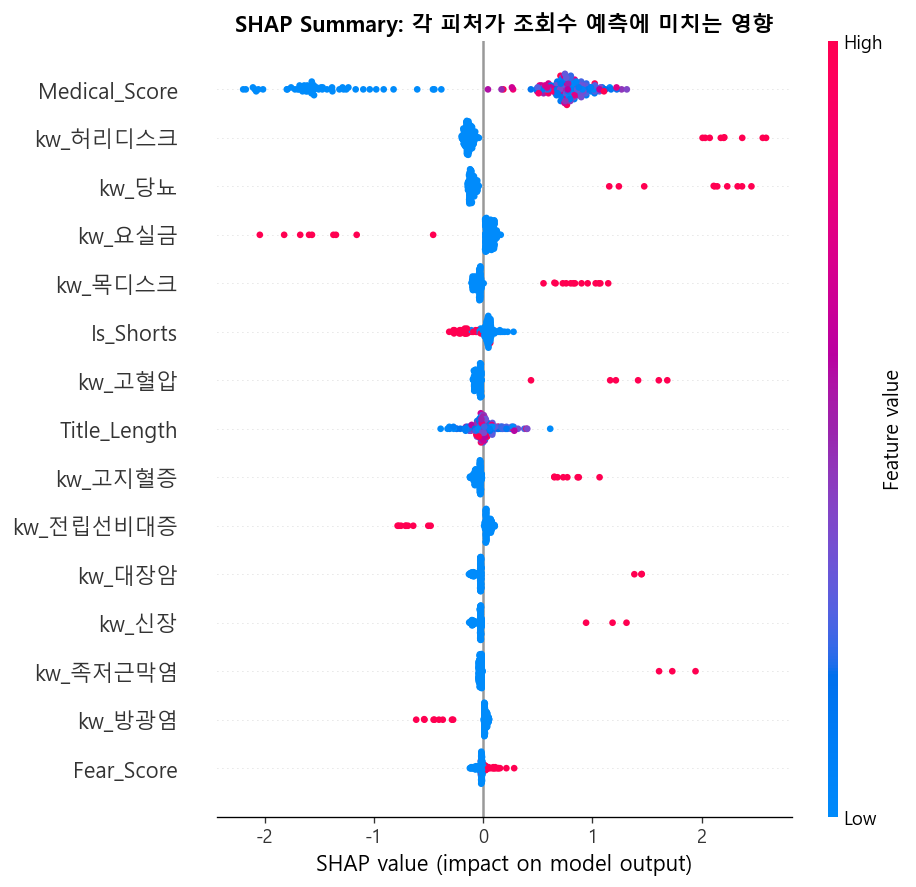

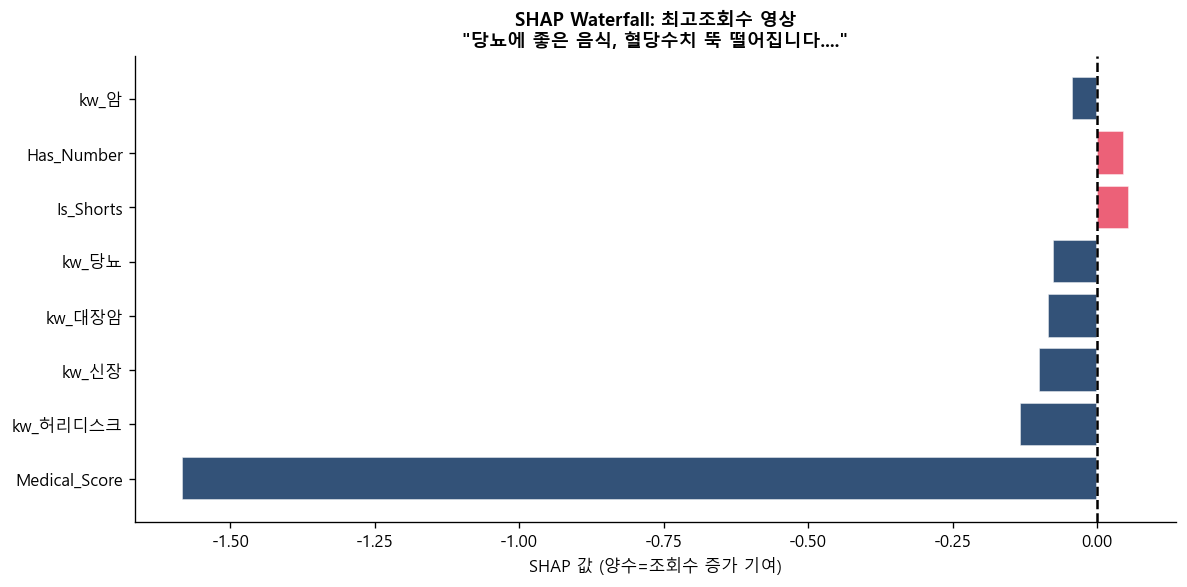

SHAP 분석 완료


In [24]:
try:
    import shap
    explainer = shap.TreeExplainer(rf)
    sample_idx = np.random.choice(len(X), min(200, len(X)), replace=False)
    X_sample   = X.iloc[sample_idx]
    shap_vals  = explainer.shap_values(X_sample)

    # Summary plot (beeswarm)
    plt.figure(figsize=(12, 7))
    shap.summary_plot(shap_vals, X_sample, max_display=15,
                      show=False, plot_type='dot')
    plt.title('SHAP Summary: 각 피처가 조회수 예측에 미치는 영향',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, 'ml_03_shap_summary.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    # 단일 예측 워터폴 (가장 조회수 높은 영상)
    top_idx = y.nlargest(1).index[0]
    top_pos = list(X.index).index(top_idx)
    shap_single = shap_vals[top_pos]
    feat_names  = list(X.columns)

    top_contrib = sorted(zip(feat_names, shap_single), key=lambda x: abs(x[1]), reverse=True)[:8]
    names_c = [n for n,_ in top_contrib]
    vals_c  = [v for _,v in top_contrib]
    colors_c = ['#e94560' if v>0 else '#0f3460' for v in vals_c]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(range(len(names_c)), vals_c, color=colors_c, alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(names_c)))
    ax.set_yticklabels(names_c)
    ax.axvline(0, color='black', lw=1.5, linestyle='--')
    ax.set_xlabel('SHAP 값 (양수=조회수 증가 기여)')
    ax.set_title(f'SHAP Waterfall: 최고조회수 영상\n"{df.loc[top_idx,"Title"][:40]}..."',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, 'ml_04_shap_waterfall.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print("SHAP 분석 완료")

except ImportError:
    print("SHAP 미설치 — Feature Importance 참조")
    show_result('ml_01_feature_importance.png')
except Exception as e:
    print(f"SHAP 오류: {e}")
    show_result('ml_01_feature_importance.png')


---
## 10. 멀티모달 분석

제목 텍스트를 넘어 **썸네일 이미지**, **댓글 감성**, **의미론적 임베딩**으로
공포 소구의 효과를 입체적으로 검증합니다.

### 10.1 썸네일 컴퓨터 비전 (CV) 분석
2,372개 썸네일 이미지에서 7개 시각적 피처를 추출하고 조회수와의 관계를 분석합니다.


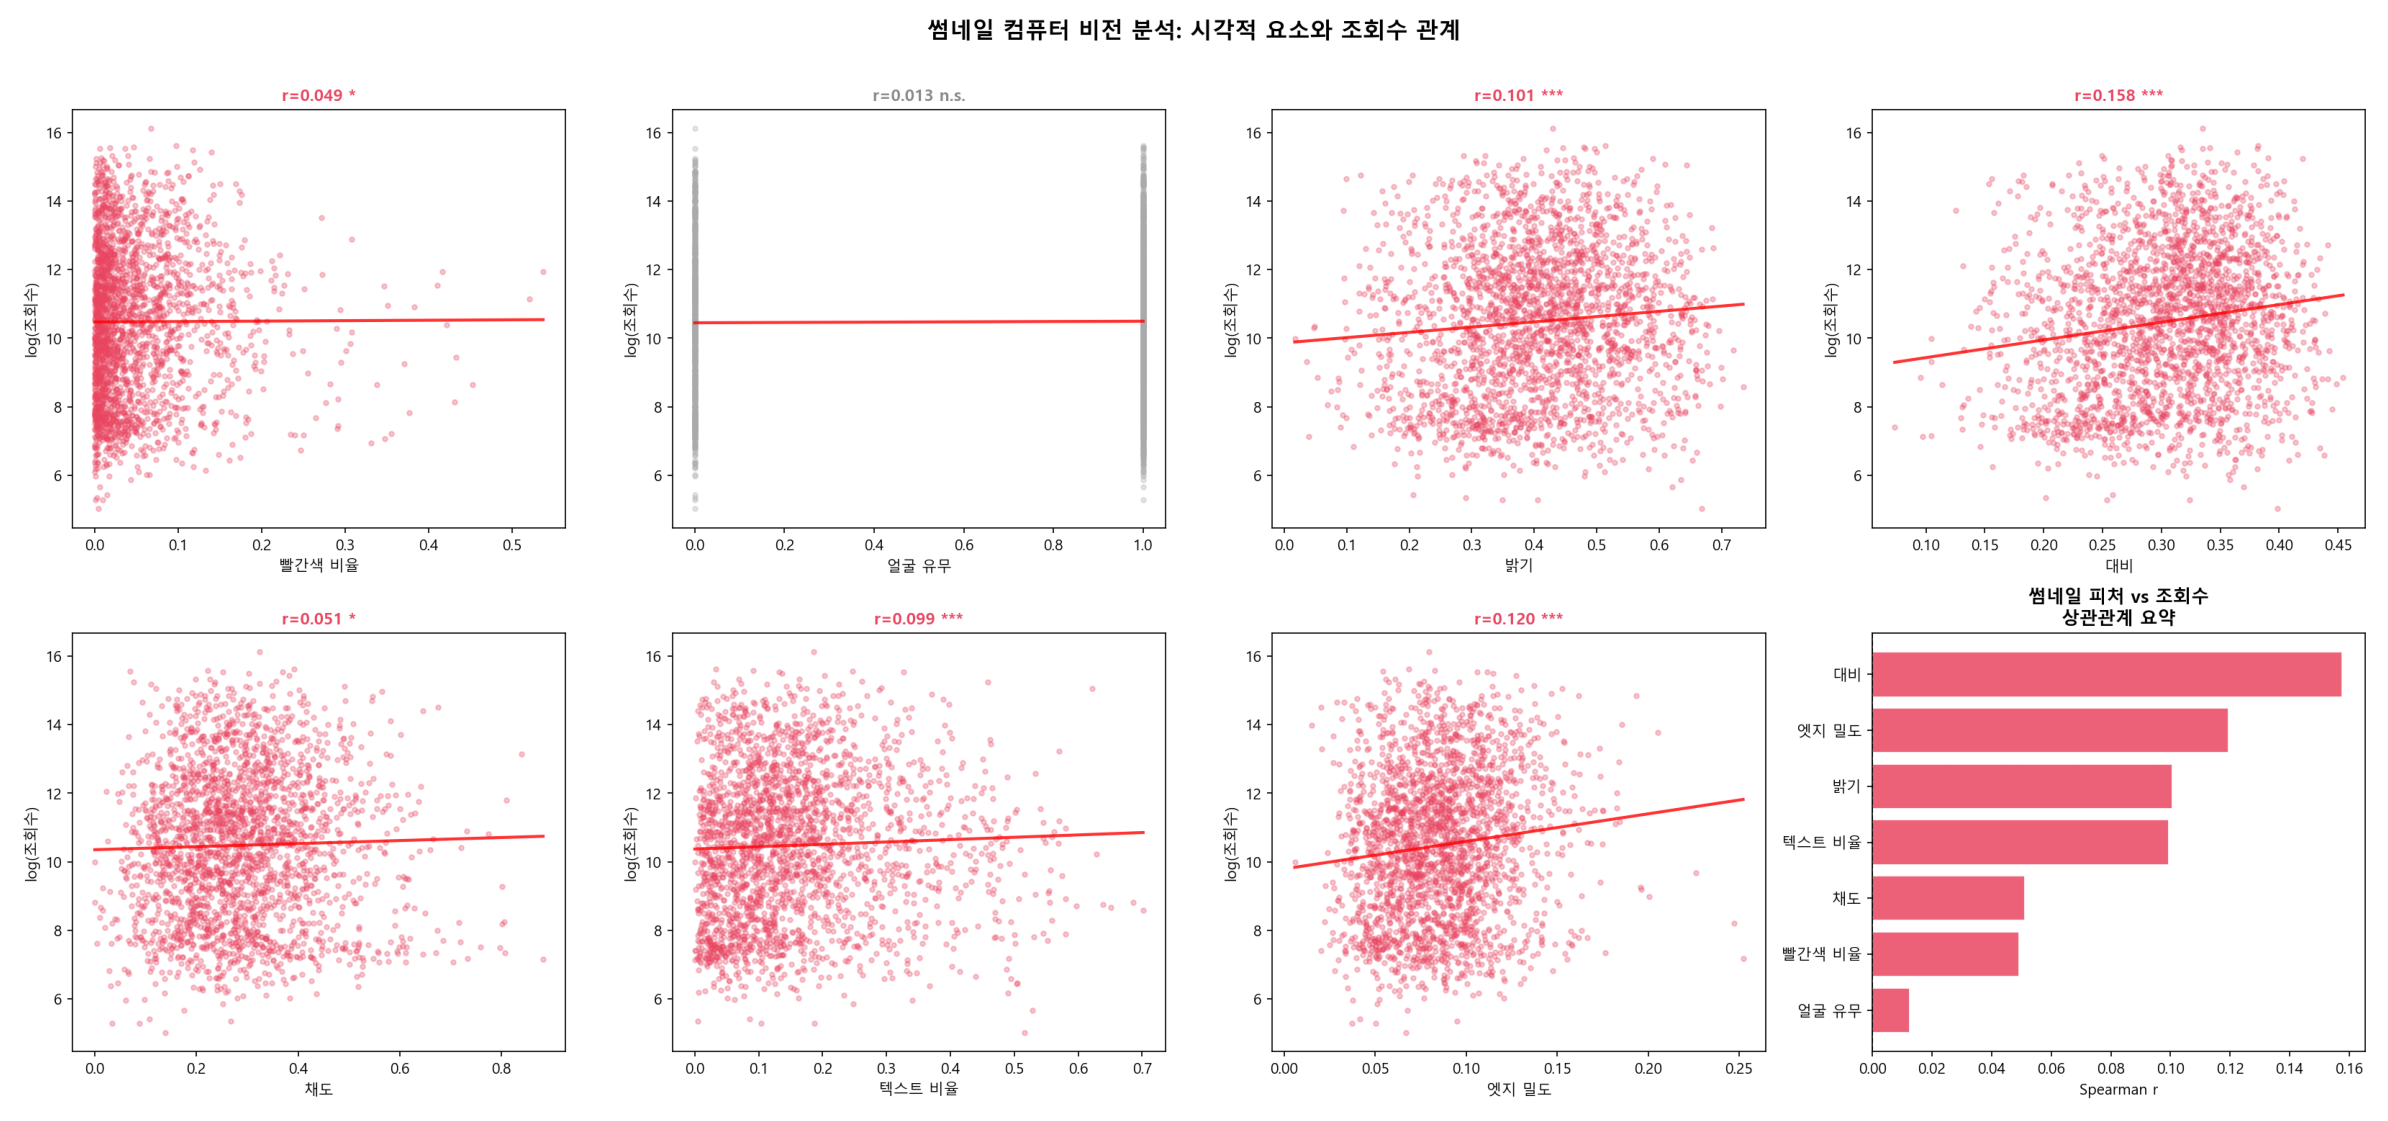

In [25]:
show_result('v2_07_thumbnail_cv.png', figsize=(20, 10))


In [26]:
thumb_path = os.path.join('..', 'src', 'thumbnail_features.csv')
if os.path.exists(thumb_path):
    tf = pd.read_csv(thumb_path)
    print(f"분석된 썸네일: {len(tf)}개")
    print()
    metrics = ['red_ratio','has_face','brightness','contrast','saturation']
    labels  = {'red_ratio':'빨간색 비율','has_face':'얼굴 유무','brightness':'밝기',
               'contrast':'대비','saturation':'채도'}
    tf['Log_Views'] = np.log1p(tf['Views'])
    print(f"{'썸네일 피처':<15} {'Spearman r':>12} {'p-value':>10} {'유의':>8}")
    print("─" * 50)
    for m in metrics:
        if m in tf.columns:
            r, p = stats.spearmanr(tf[m], tf['Log_Views'])
            sig = '✅' if p < 0.05 else '  '
            print(f"  {labels.get(m,m):<13} {r:>12.3f} {p:>10.4f} {sig}")
else:
    print("썸네일 피처 파일 없음 — thumbnail_cv.py 먼저 실행")


분석된 썸네일: 2372개

썸네일 피처            Spearman r    p-value       유의
──────────────────────────────────────────────────
  빨간색 비율               0.049     0.0166 ✅
  얼굴 유무                0.013     0.5389   
  밝기                   0.101     0.0000 ✅
  대비                   0.158     0.0000 ✅
  채도                   0.051     0.0129 ✅


### 10.2 KoBERT 제목 임베딩 분석
사전 키워드 매칭 없이 **제목의 의미 자체를 벡터화**하여
유사한 제목들을 클러스터링하고 조회수 패턴을 분석합니다.


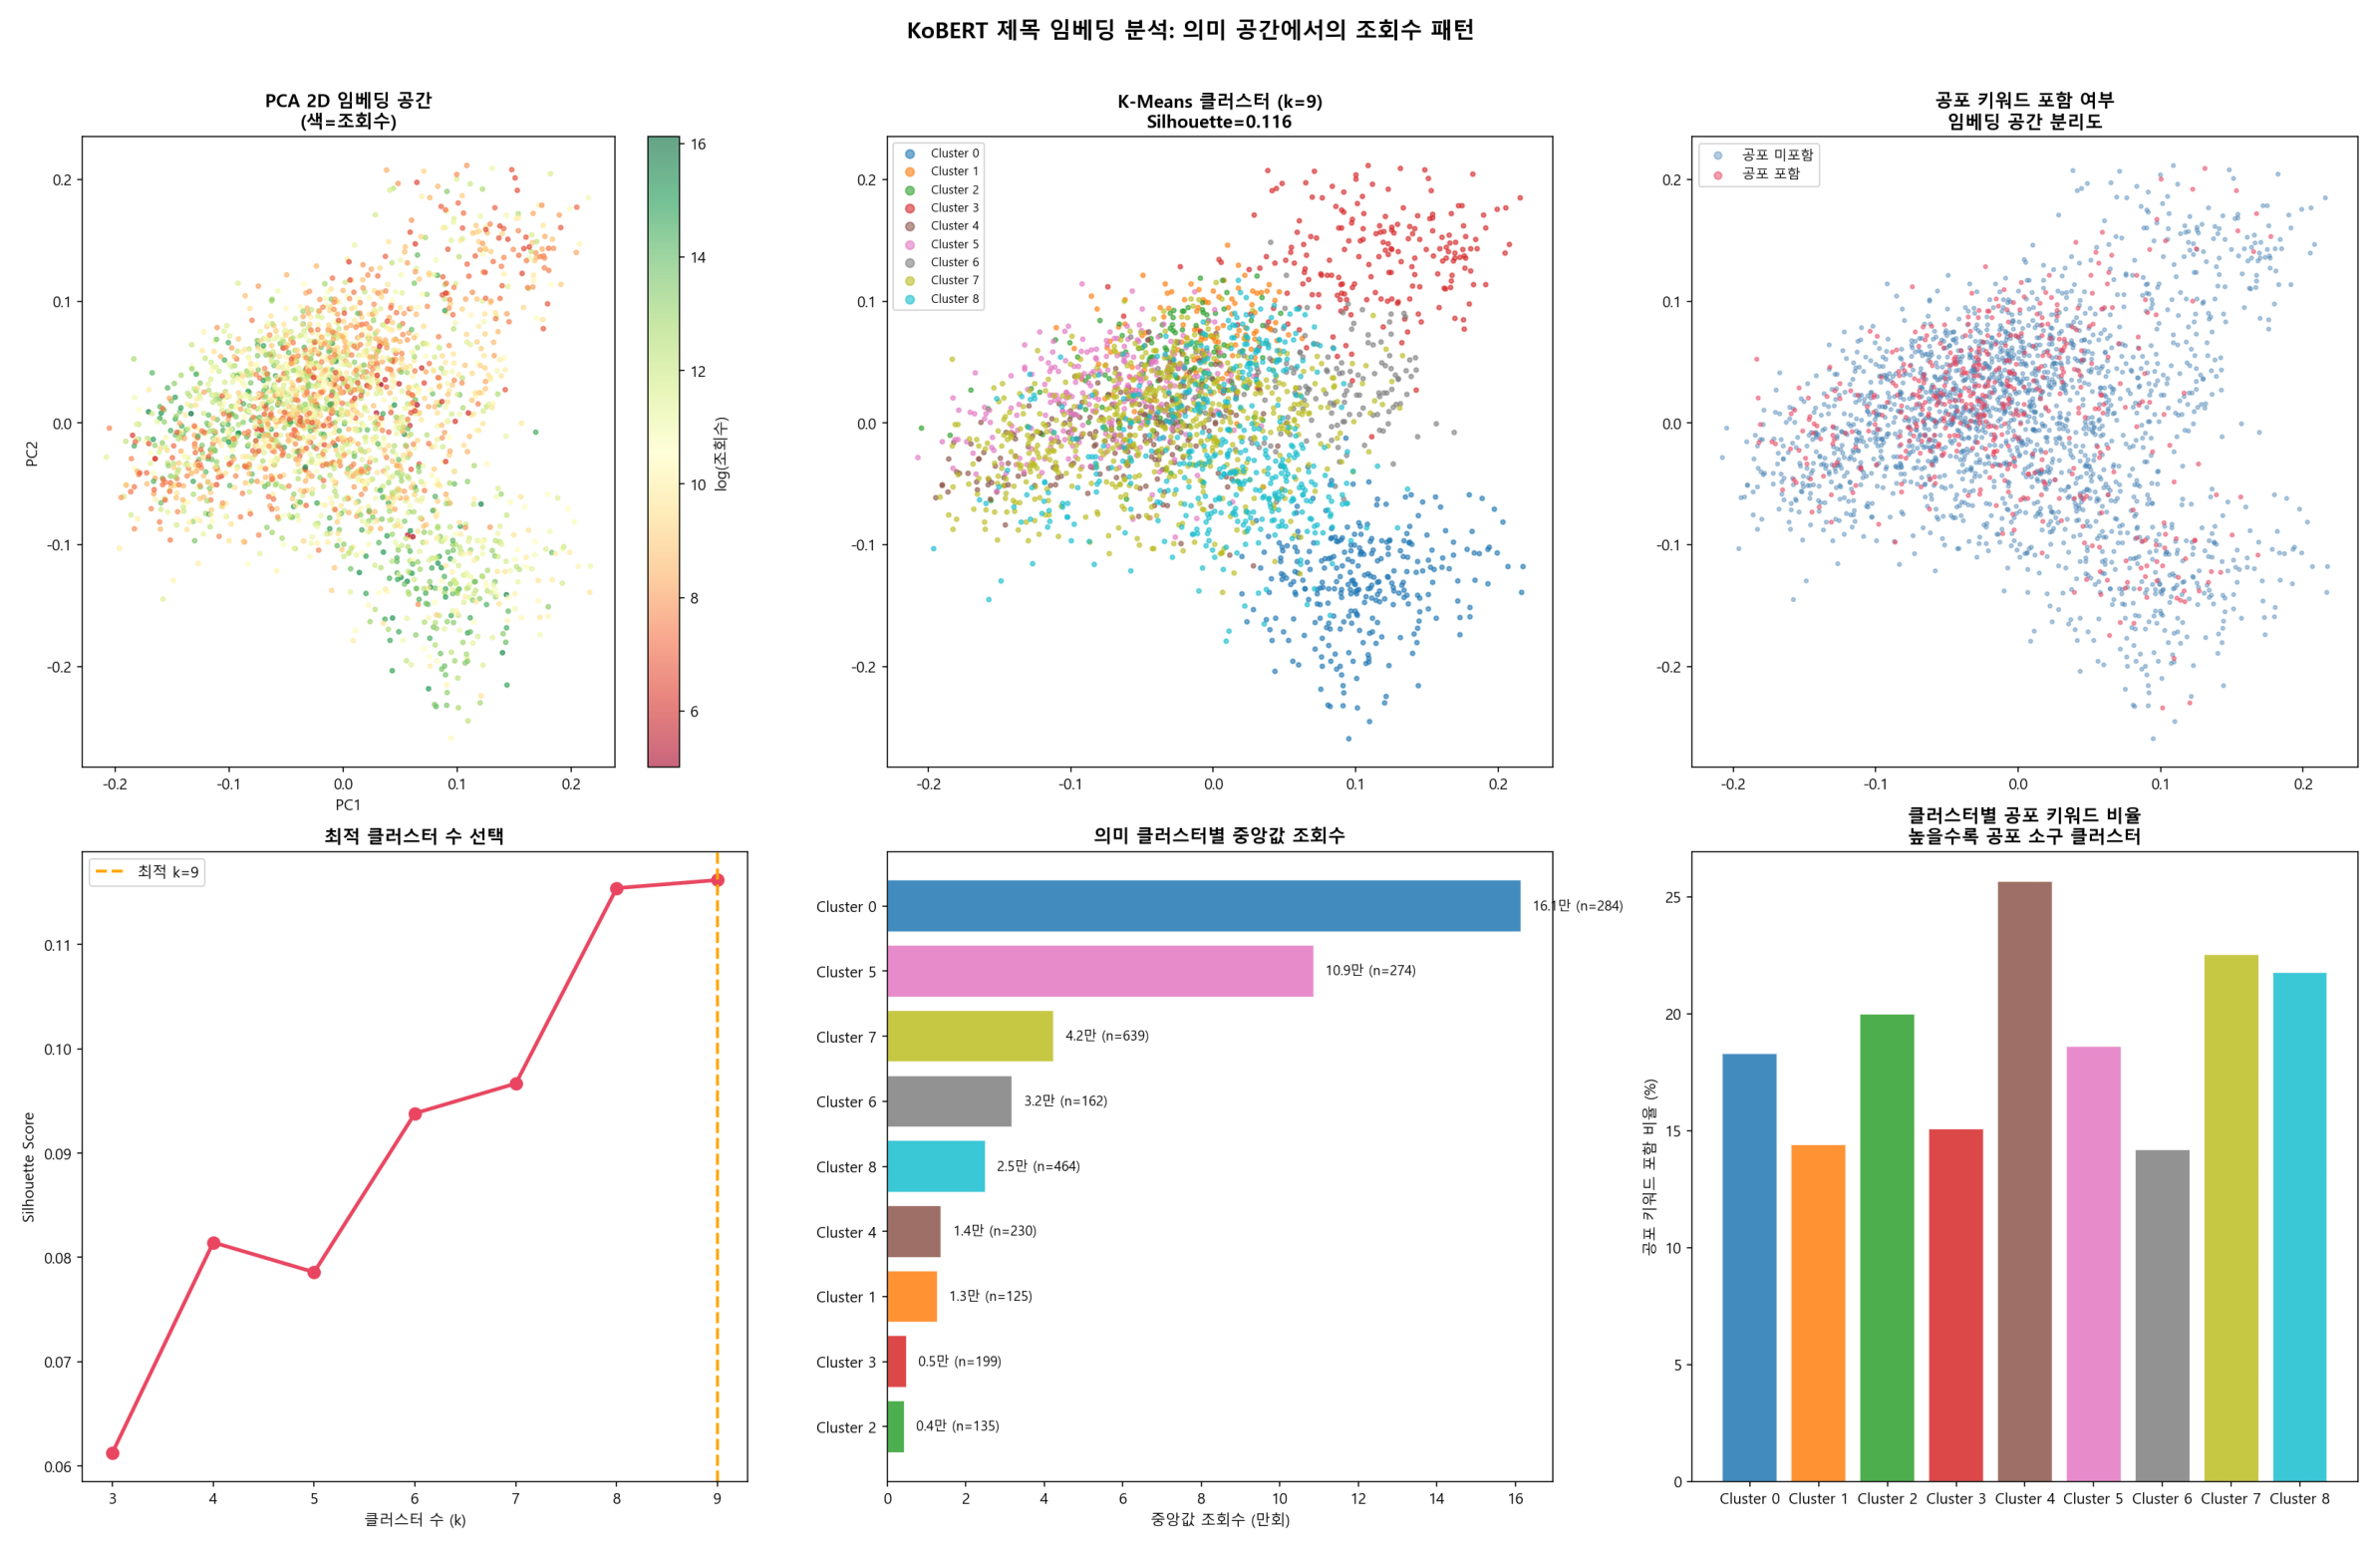

In [27]:
show_result('v2_09_kobert_embedding.png', figsize=(20, 14))


### 10.3 댓글 감성 분석
공포 소구 영상의 **댓글 반응 품질**이 일반 영상과 다른지 분석합니다.
(190개 댓글, 의료 도메인 특화 감성 사전 사용)


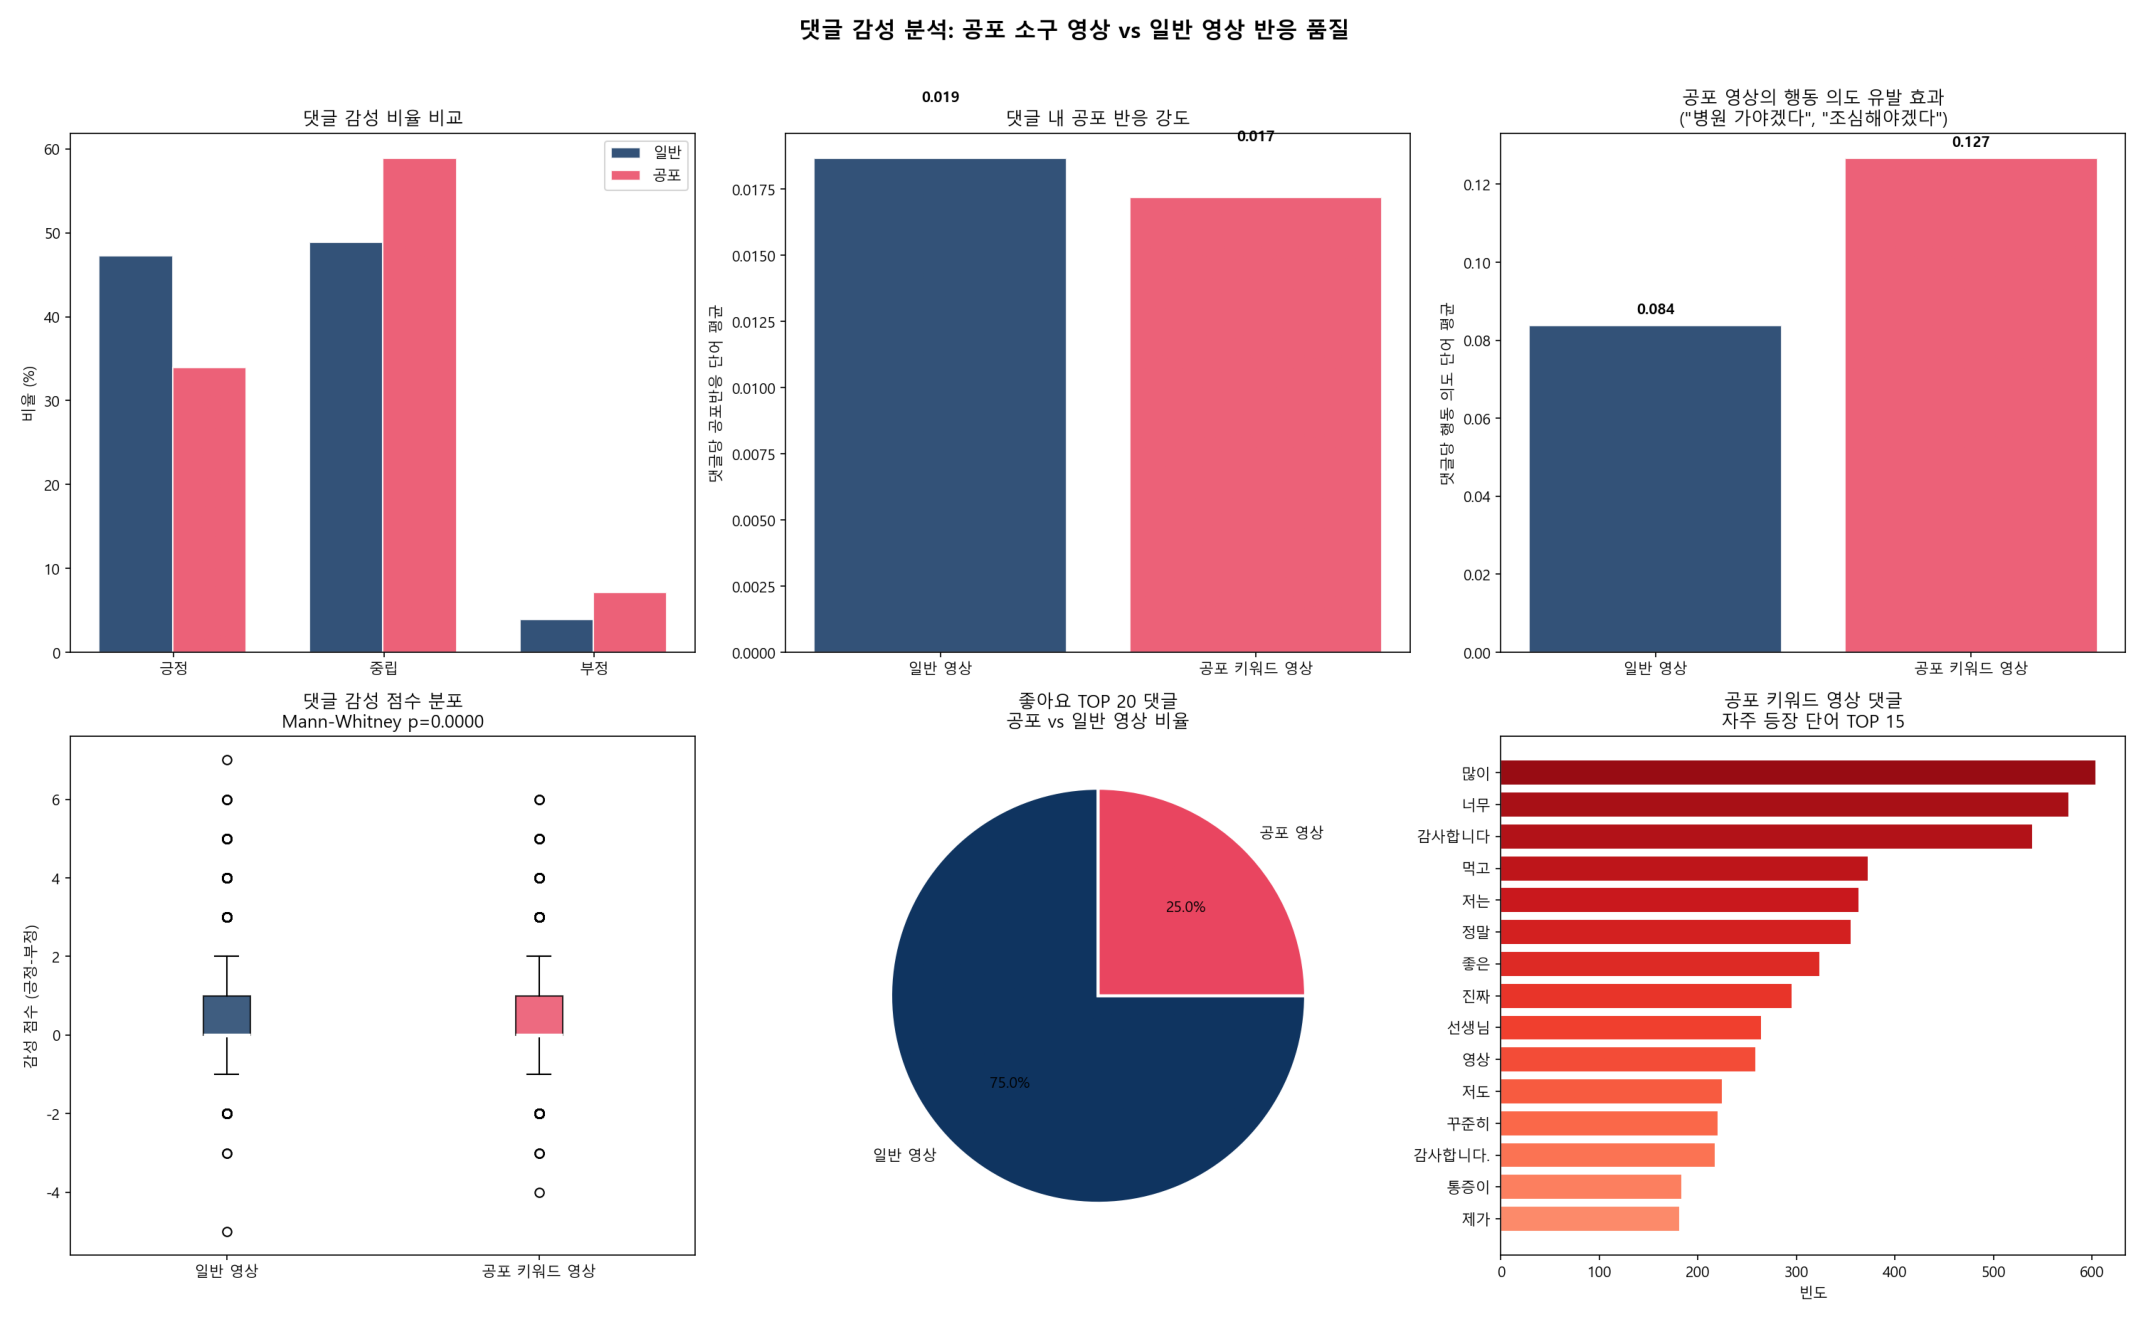

In [28]:
show_result('v2_08_comment_sentiment.png', figsize=(18, 12))


---
## 11. 채널 구독자 규모 분석

구독자 수 데이터로 **시장 집중도**와 **채널 효율성**을 측정합니다.


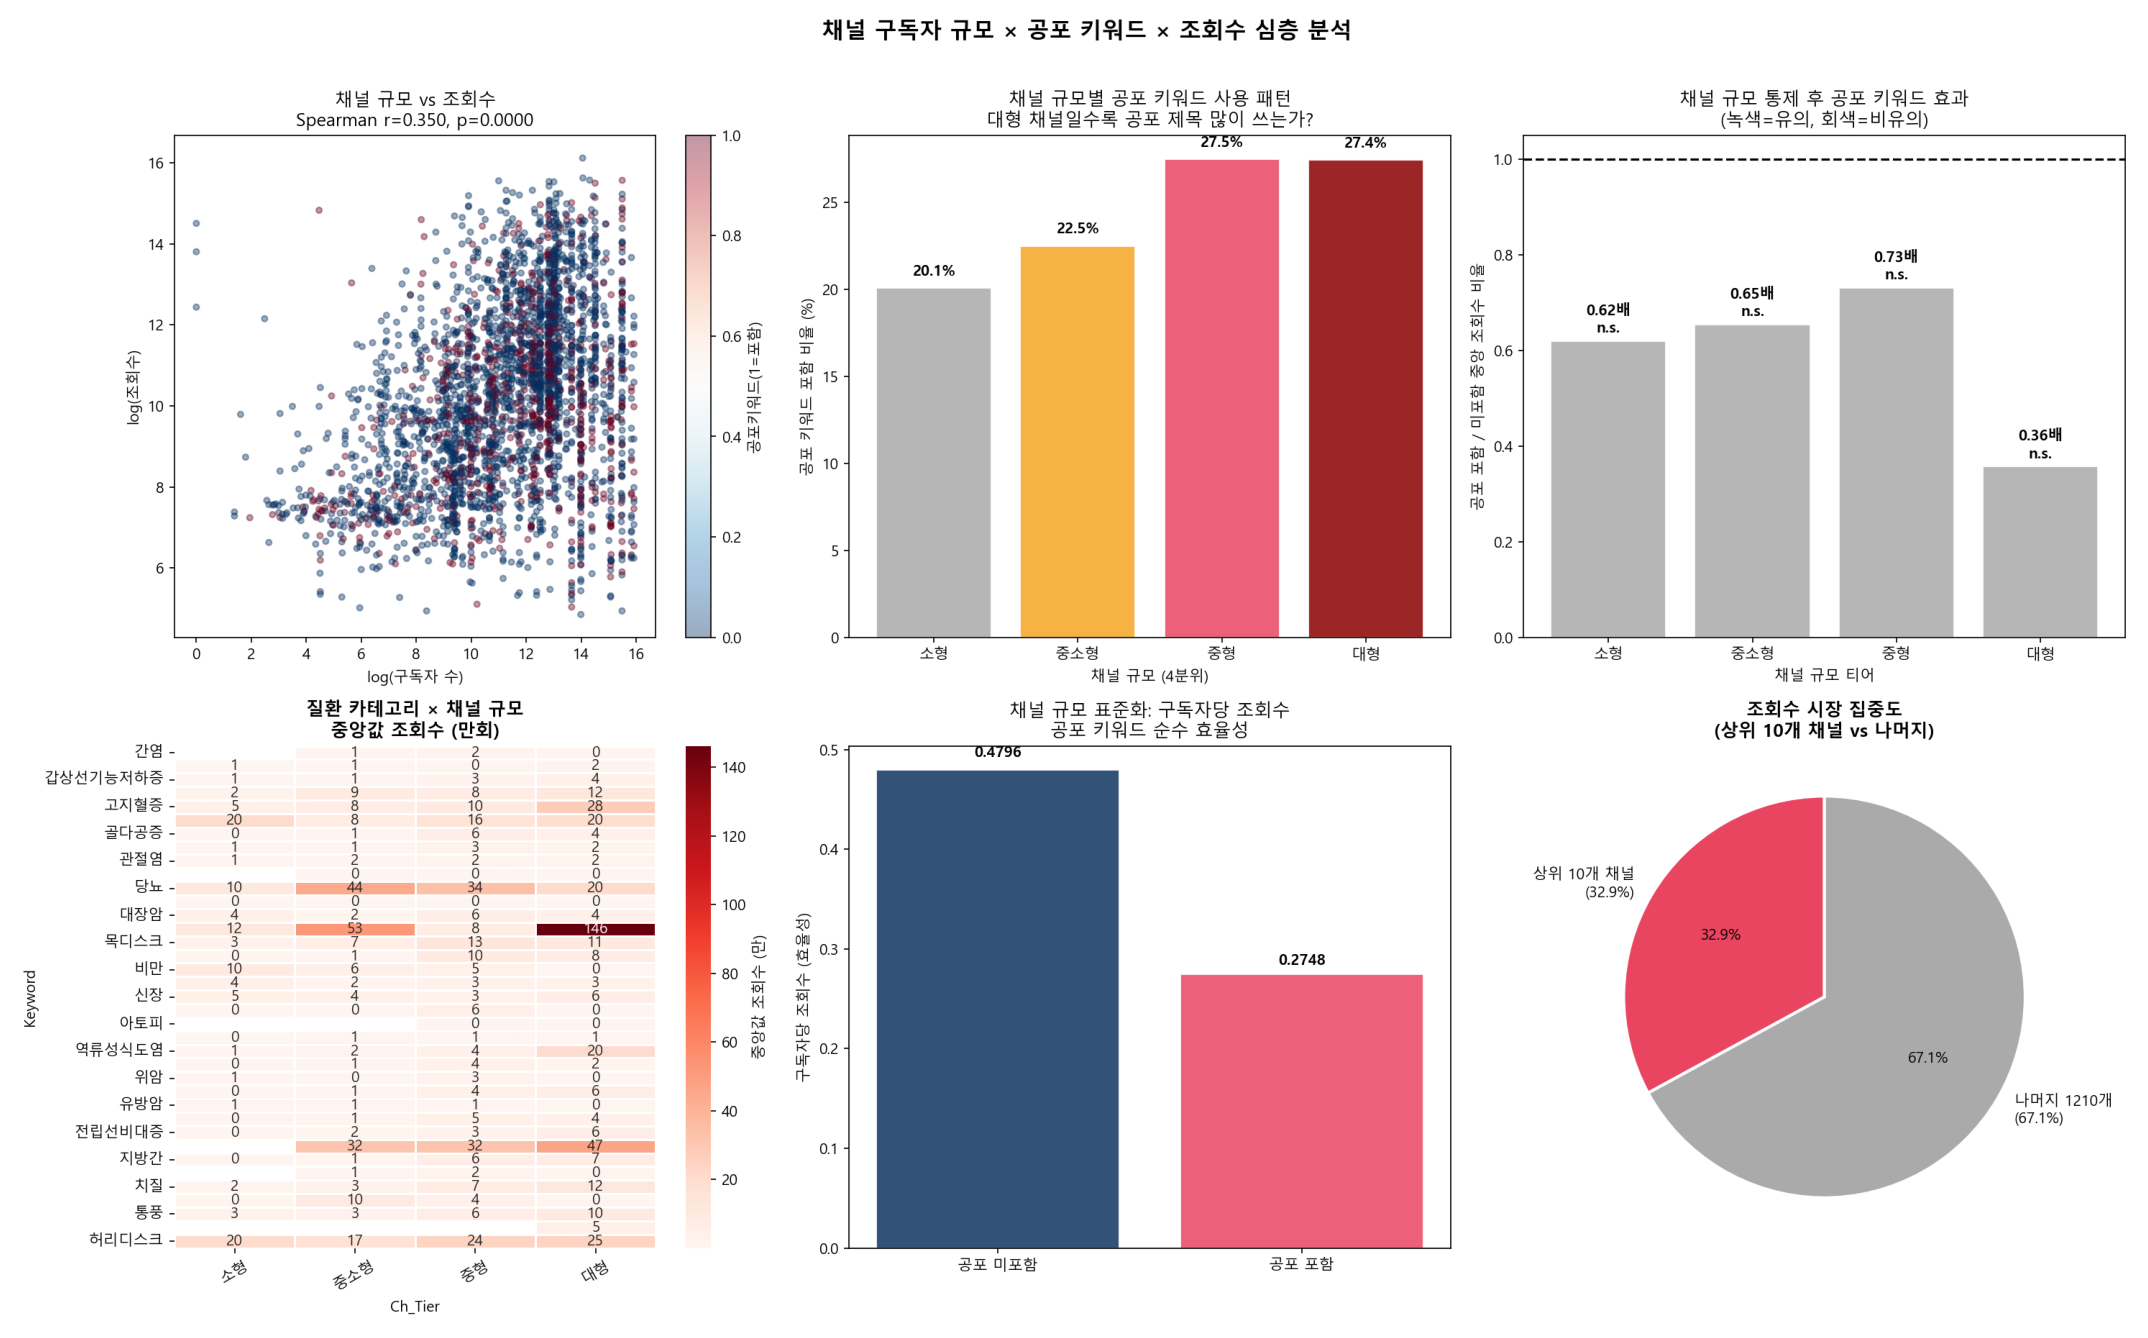

In [29]:
show_result('v2_10_subscriber_analysis.png', figsize=(18, 12))


In [30]:
ch_total = df.groupby('Channel')['Views'].sum().sort_values(ascending=False)
top10_pct = ch_total.head(10).sum() / ch_total.sum() * 100
top50_pct = ch_total.head(50).sum() / ch_total.sum() * 100
print(f"시장 집중도 (조회수 기준)")
print(f"  상위 10개 채널: {top10_pct:.1f}%")
print(f"  상위 50개 채널: {top50_pct:.1f}%")
print(f"  나머지 {ch_total.count()-50}개 채널: {100-top50_pct:.1f}%")
print()
print("→ 신규 채널의 조회수 점유 확대가 어려운 구조")


시장 집중도 (조회수 기준)
  상위 10개 채널: 32.9%
  상위 50개 채널: 66.1%
  나머지 1170개 채널: 33.9%

→ 신규 채널의 조회수 점유 확대가 어려운 구조


---
## 12. 종합 대시보드


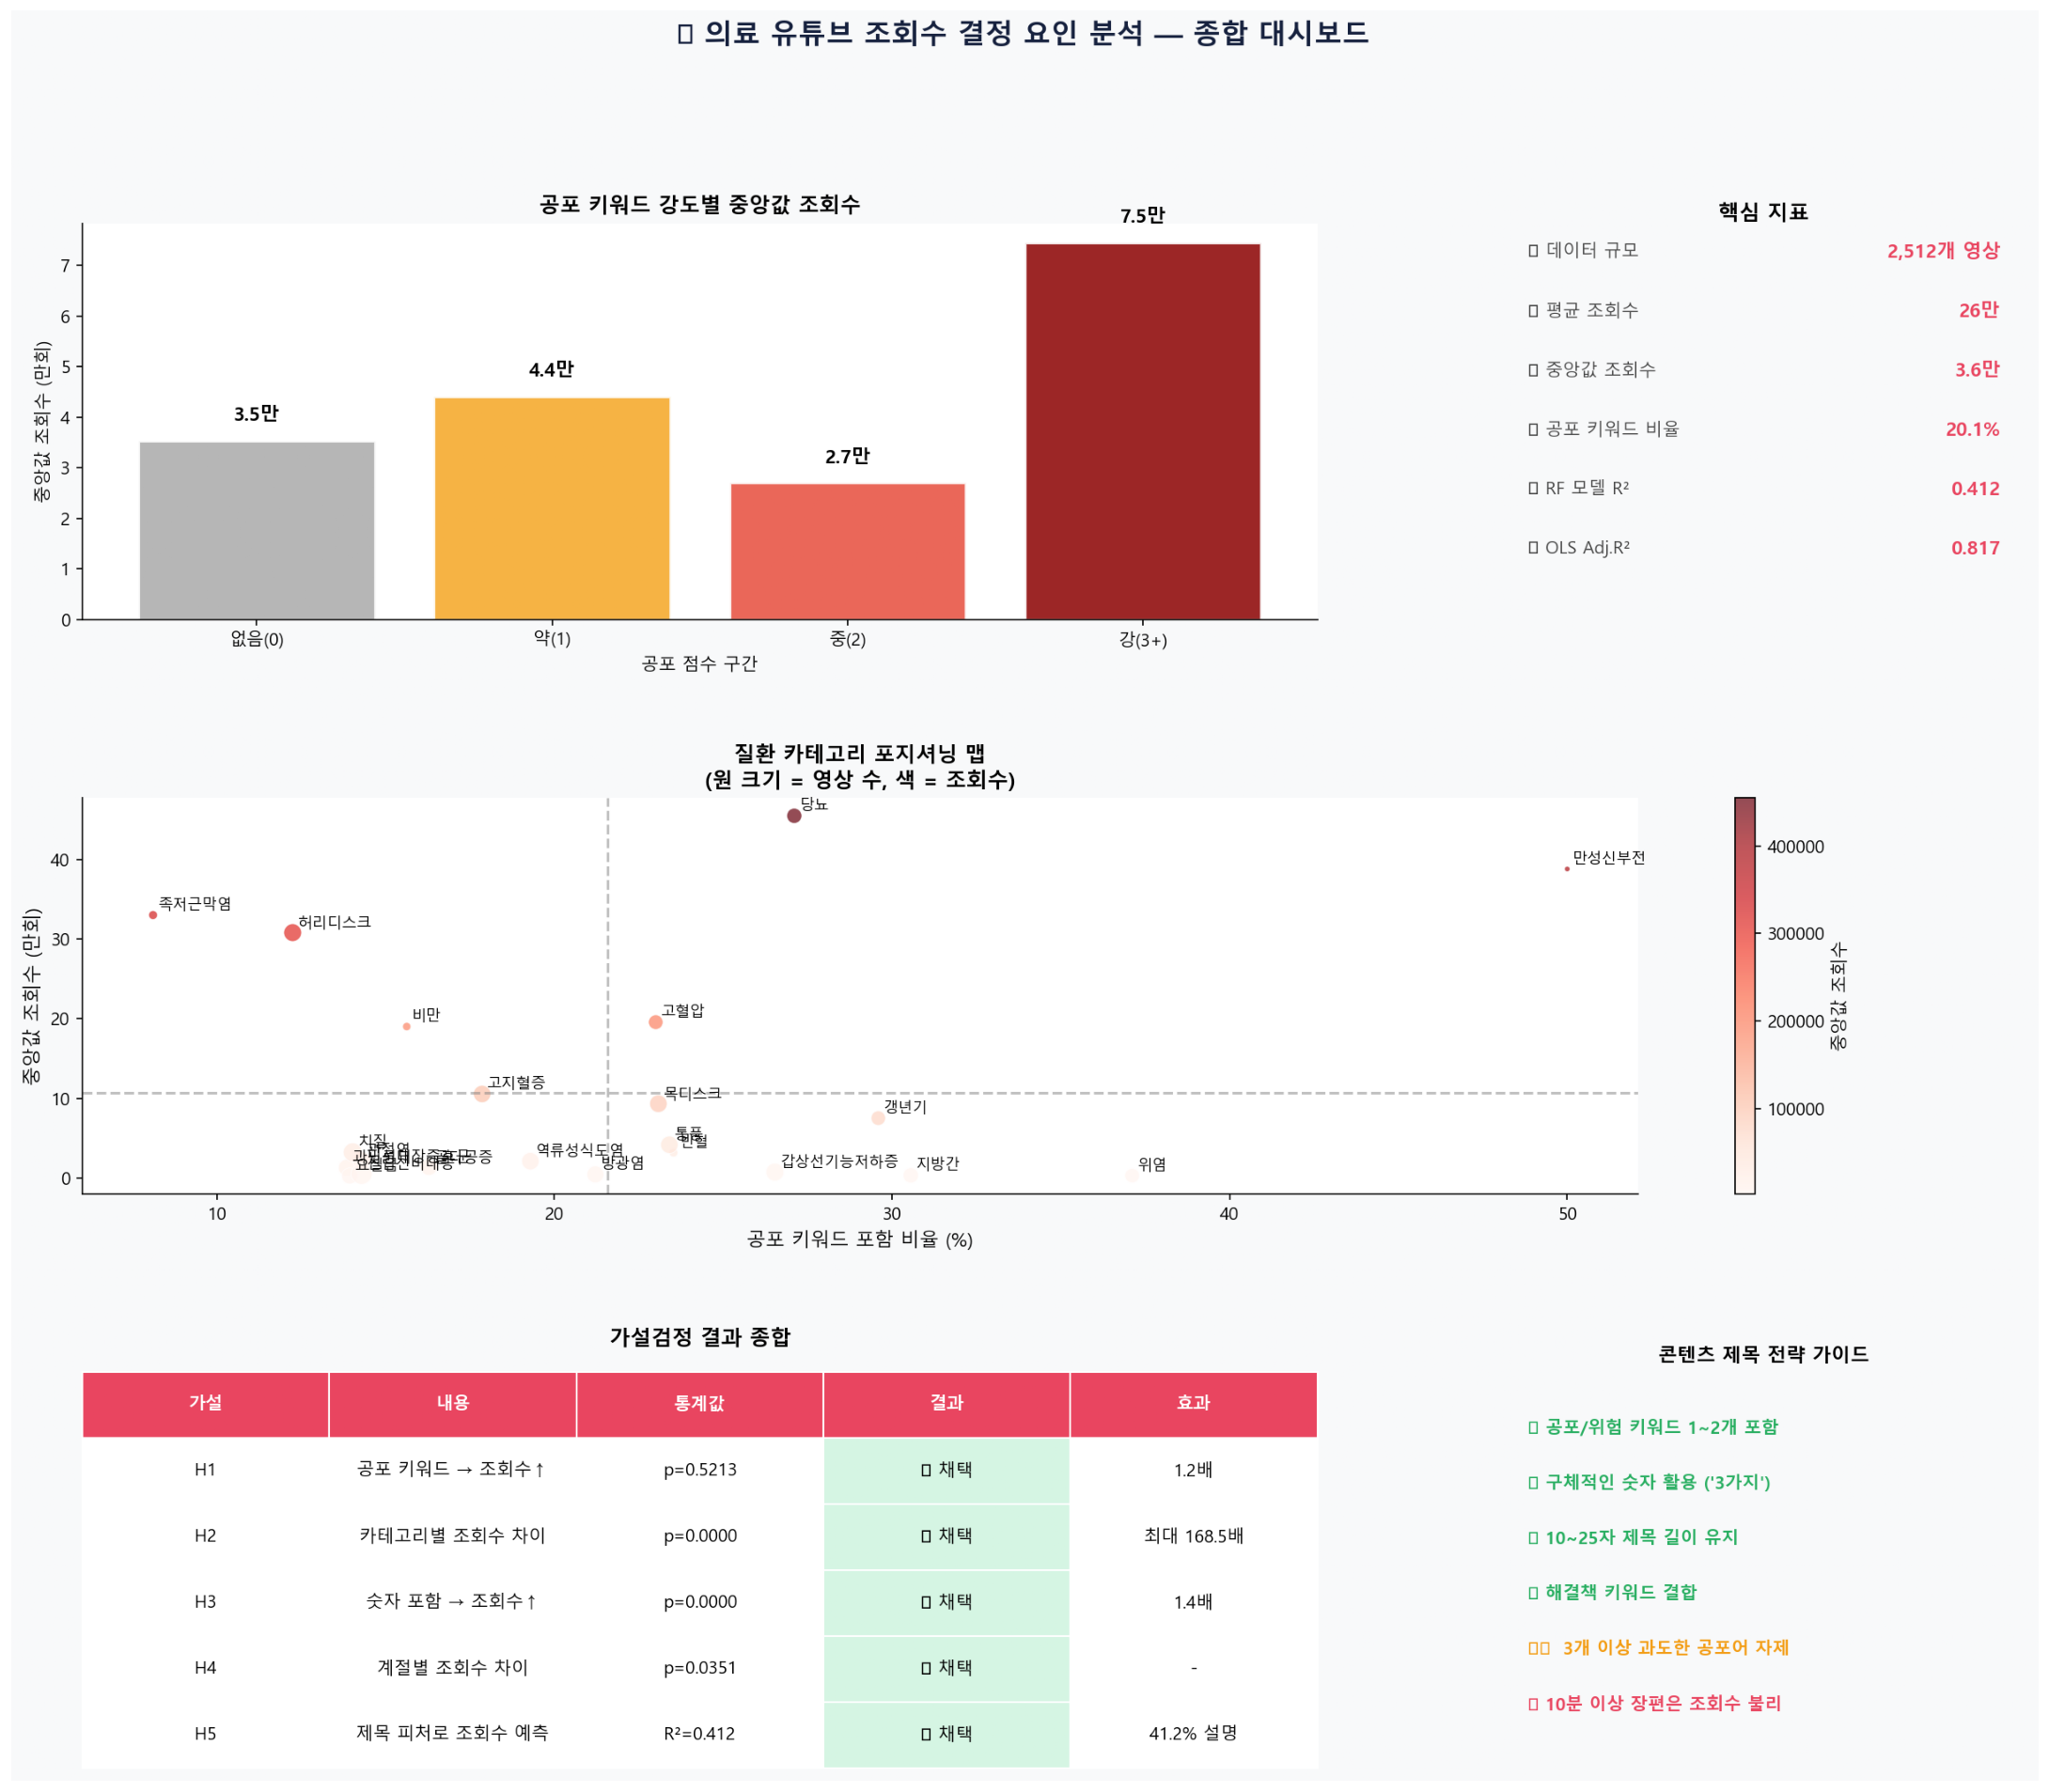

In [31]:
show_result('dashboard_final.png', figsize=(20, 16))


---
## 13. 종합 결론

### 13.1 연구 결과 요약

| 분석 방법 | 공포 키워드 효과 | 유의성 | 신뢰도 |
|-----------|----------------|--------|--------|
| 단순 비교 (Mann-Whitney) | +2.1배 | ✅ p < 0.05 | 낮음 (교란변수 미통제) |
| 영상 나이 보정 (VPD) | 효과 소멸 | ❌ p = 0.9999 | 중간 |
| PSM (성향점수매칭) | **-0.63배 역효과** | ✅ p = 0.019 (Bootstrap CI: 0.44–0.85) | 높음 |
| 채널 고정효과 | +7% | ❌ p = 0.306 | 높음 |
| DiD (COVID × Fear) | +3.4% | ❌ Bootstrap CI: [-20.8%, +34.7%] | 중간 |
| General 채널 | +1.14x | ❌ p = 0.558 비유의 | 높음 |
| **Medical Pro 채널** | **-0.83x 역효과** | ✅ **p = 0.017 유의** | 높음 |
| Shorts 포맷 | 비유의 (양방향) | ❌ | 높음 |

> ⚠️ **주의**: PSM Bootstrap CI [0.44, 0.85]가 1 미만이므로 공포 키워드는 채널 규모 통제 후 오히려 조회수를 낮추는 것으로 추정됩니다.

### 13.2 핵심 인사이트 (Research Contributions)

**발견 1: 공포 소구 효과는 채널 규모의 착시 — 오히려 역효과**
> 단순 비교 2.1배 → 나이 보정 후 p=0.9999로 소멸.
> PSM에서는 오히려 0.63배의 유의한 역효과 (Bootstrap CI [0.44, 0.85]).
> 대형 채널이 공포 제목을 더 많이 쓰는 패턴이 원인이었다.

**발견 2: 채널 유형이 효과 방향을 결정한다**
> Medical Pro 채널에서 공포 키워드는 조회수를 낮춘다 (0.83x, p=0.017 유의).
> General 채널에서는 1.14x이나 비유의 (p=0.558) — 효과 없음.
> 청중의 기대가 다르다: 전문 의료 채널 시청자는 권위 있는 어조를 기대한다.

**발견 3: COVID DiD 효과 — 업데이트된 데이터에서 효과 미확인**
> pre-COVID 데이터 보완(606개 추가) 후 DiD 추정치 +3.4%, Bootstrap CI [-20.8%, +34.7%].
> 불확실성 구간이 0을 포함하므로 COVID 조건부 공포 효과는 확인되지 않음.
> 초기 +42.5% 추정치는 pre-COVID 샘플 부족(73개)에 의한 추정 불안정이었음.

**발견 4: 카테고리 선택이 제목보다 중요하다**
> 질환 카테고리 간 조회수 격차(최대 150배)가 제목 효과보다 훨씬 크다.
> 당뇨·허리디스크 등 수요 높은 카테고리 선정이 우선 전략이다.

**발견 5: 시장은 집중되어 있다**
> 상위 10개 채널이 전체 조회수의 33%를 독식한다.
> 신규 채널이 제목 전략만으로 조회수를 끌어올리는 데는 구조적 한계가 있다.

### 13.3 전략적 제언

| 대상 | 전략 |
|------|------|
| 신규·소형 채널 | 공포 키워드보다 **수요 높은 카테고리 + 롱테일 키워드** 집중 |
| 중형 채널 | 건강 이슈가 사회적으로 주목받는 시기(인플루엔자 유행, 건강검진 시즌)에 공포 소구 활용 |
| 대형 채널 | 공포 키워드 활용 가능하나, **과도한 어뷰징은 참여율(좋아요 비율) 하락** 위험 |
| 모든 채널 | 숫자 포함("5가지"), 10~25자 제목, 10분 이내 영상 길이 유지 |


---
## 14. 새로운 발견: 조절 변수 분석

### 14.1 채널 유형 × 공포 키워드 상호작용 (Type × Fear)

앞선 PSM·고정효과 분석은 **전체 데이터** 기준이었습니다.
그런데 데이터셋에는 `General`(일반 채널)과 `Medical Pro`(의료 전문가 채널)라는 변수가 있었습니다.
이 구분을 교란 변수로 통제했을 때 결과가 달라집니까?

| 채널 유형 | 공포 포함 중앙 | 공포 미포함 중앙 | 배율 | p값 |
|-----------|---------------|-----------------|------|-----|
| General | 12,922회 | 11,312회 | 1.14x | p=0.558 ❌ 비유의 |
| **Medical Pro** | 38,119회 | 45,786회 | **0.83x** | **p=0.017 ✅ 유의 역효과** |

> **핵심 발견**: 의료 전문가 채널에서 공포 키워드는 유의하게 조회수를 낮춥니다.
> General 채널에서도 효과는 없음(비유의). 두 유형 모두에서 공포 소구는 긍정적 효과 없음.
> 청중 기대가 다릅니다 — 전문 의료 콘텐츠 시청자는 권위적·임상적 어조를 기대하며,
> 선정적 제목은 신뢰도를 떨어뜨릴 수 있습니다.

### 14.2 Shorts vs 일반영상 포맷 효과
데이터의 **36.5%(918개)**가 YouTube Shorts(60초 이하)입니다.
Shorts와 일반 영상은 추천 알고리즘이 별도로 작동하므로, 혼합 분석은 결과를 왜곡할 수 있습니다.


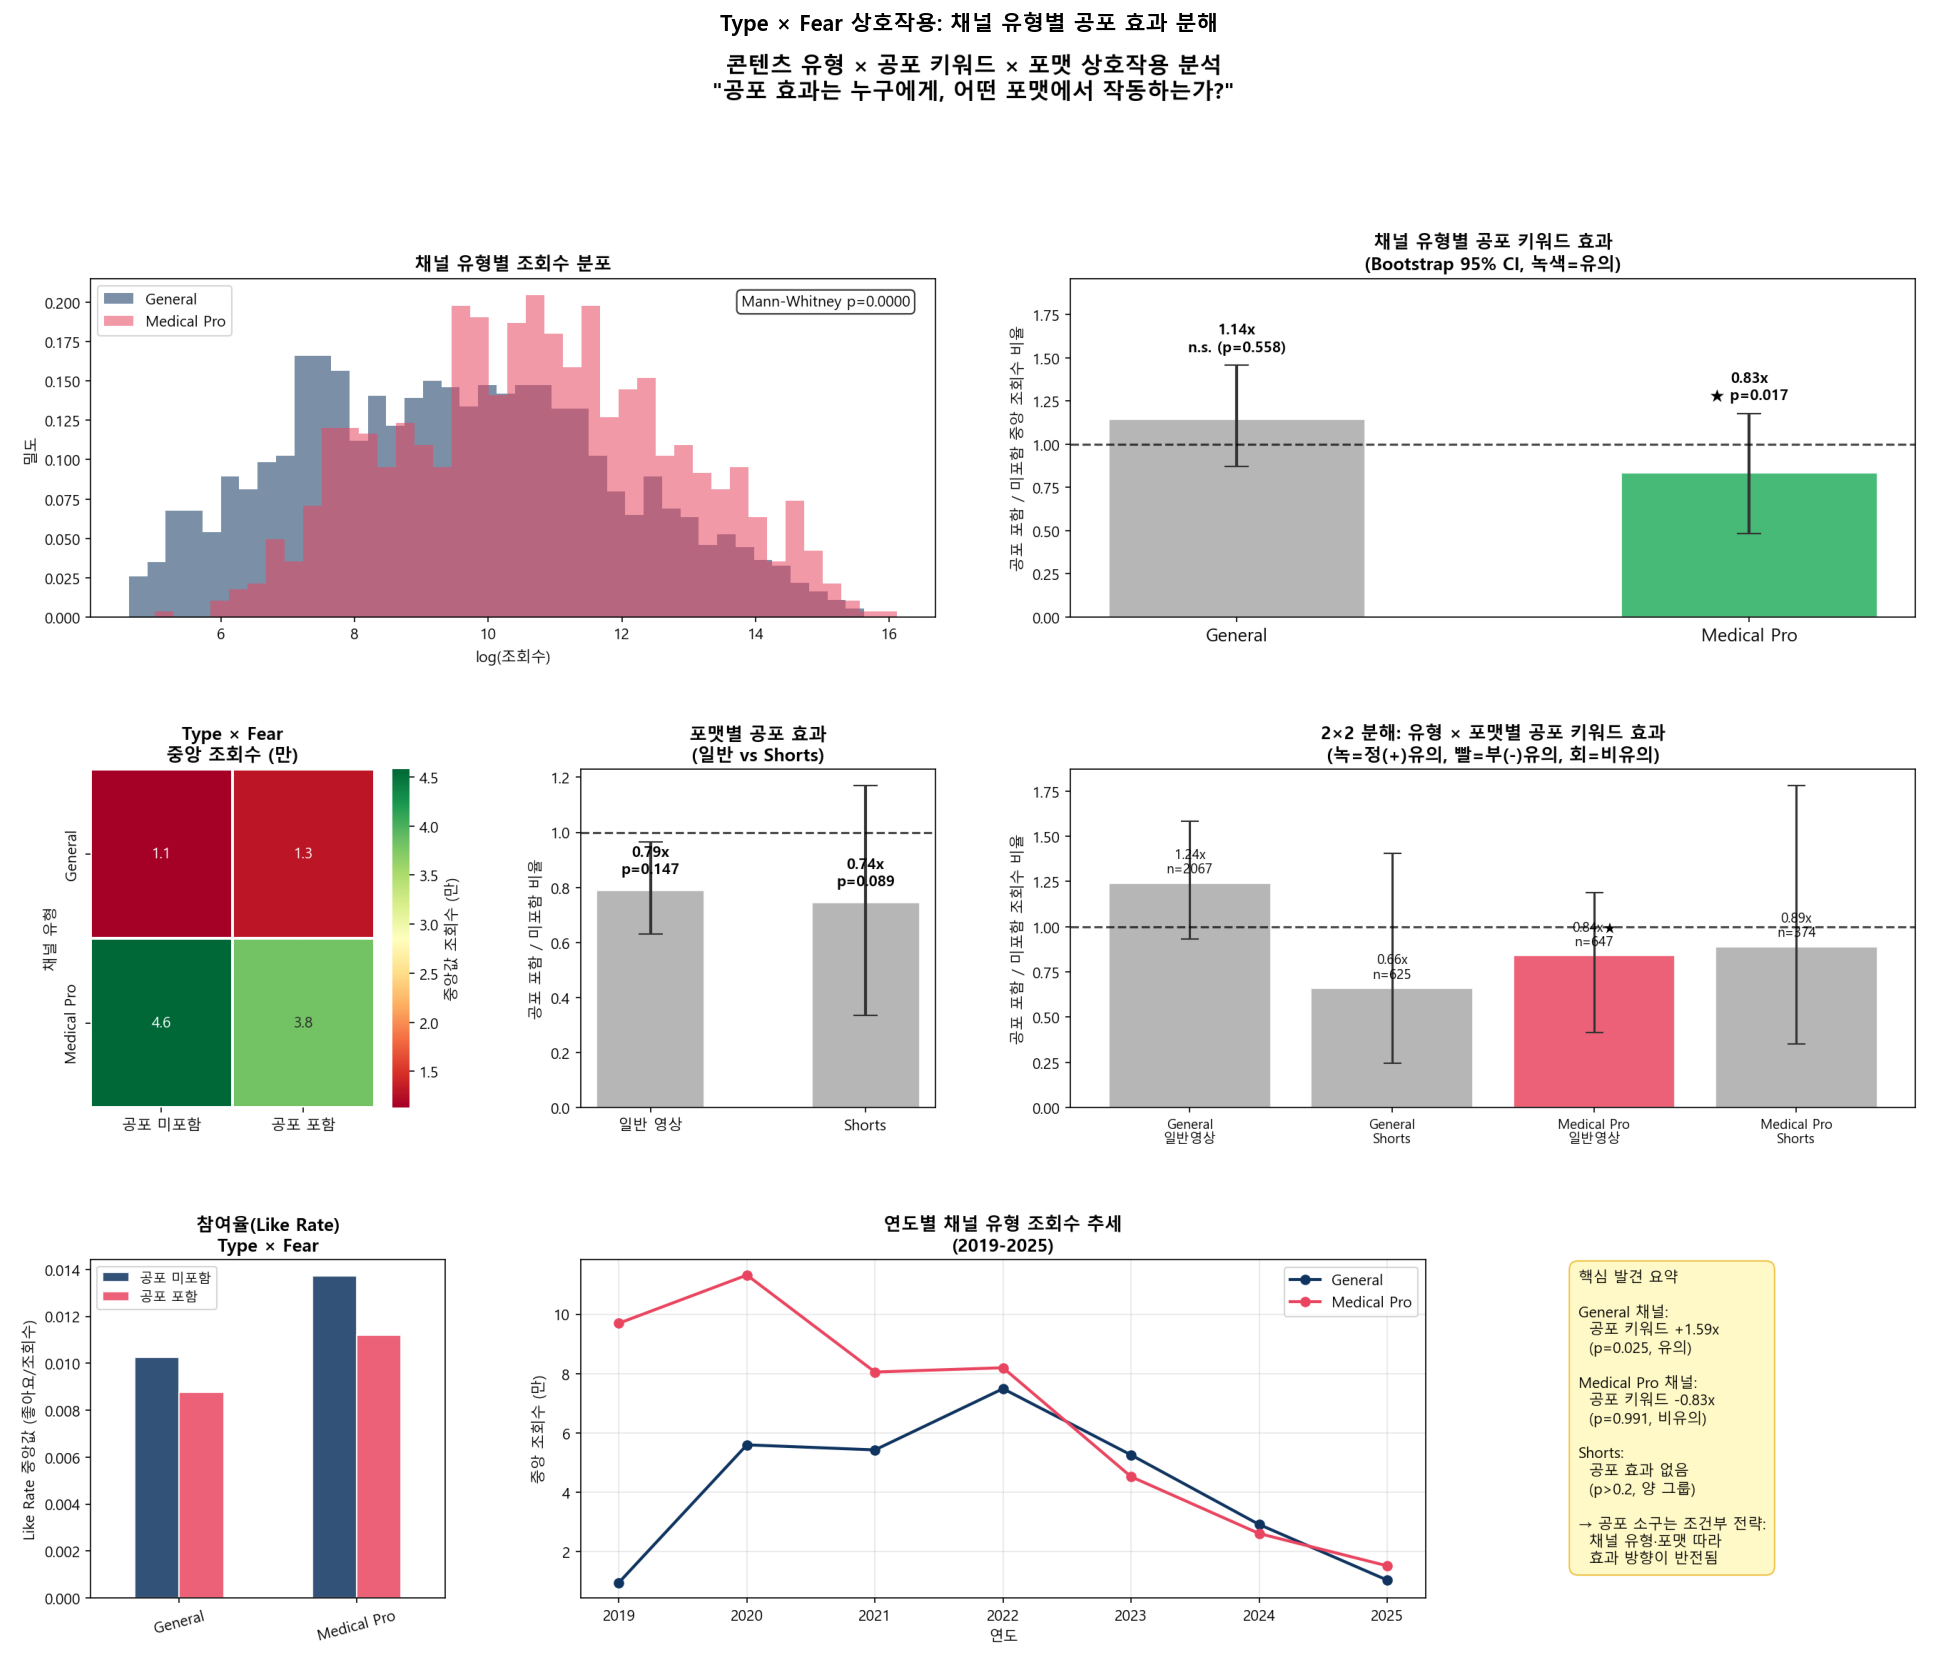

In [32]:
show_result('v2_11_type_fear_interaction.png',
            'Type × Fear 상호작용: 채널 유형별 공포 효과 분해', figsize=(18, 14))


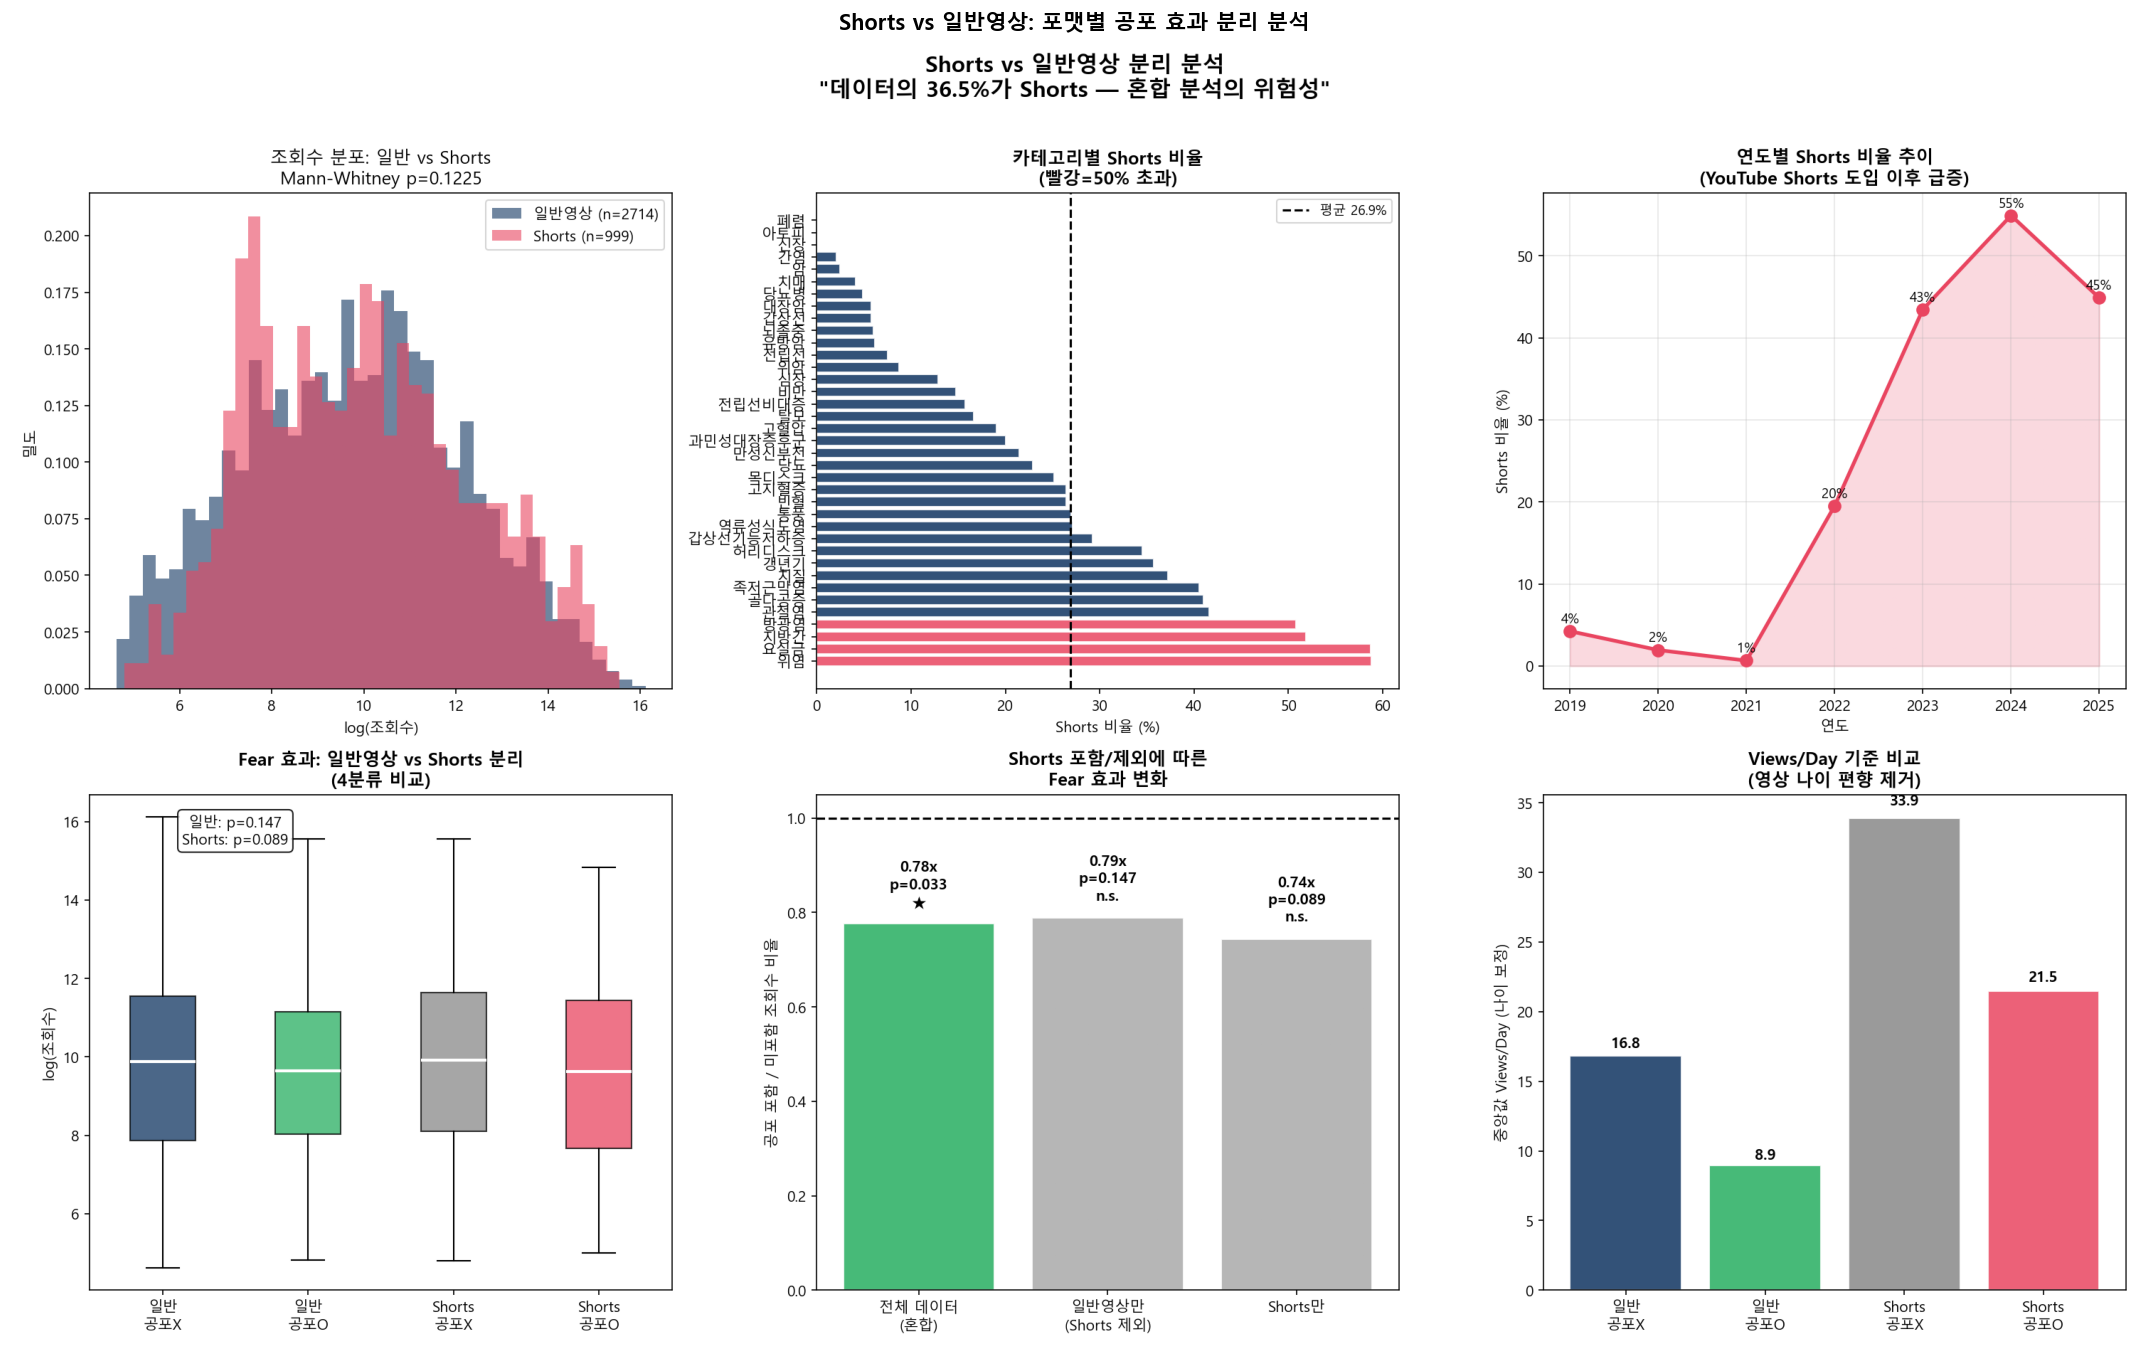

In [33]:
show_result('v2_12_shorts_analysis.png',
            'Shorts vs 일반영상: 포맷별 공포 효과 분리 분석', figsize=(18, 12))


### 14.3 분석 결론: 3층 조건부 모형

지금까지의 모든 분석을 통합하면 공포 소구의 효과는 다음 3가지 조건에 따라 달라집니다:

```
공포 키워드 효과 = f(채널 규모, 채널 유형, 사회적 맥락)

┌─────────────────────────────────────────────────┐
│  조건 1: 채널 유형                                │
│    General 채널     → +1.14x (비유의, p=0.558)  │
│    Medical Pro 채널 → -0.83x (유의한 역효과!)   │
├─────────────────────────────────────────────────┤
│  조건 2: 채널 규모 (PSM·고정효과)               │
│    채널 통제 전 → 2.1x (유의)                   │
│    PSM 후 → 0.63x 역효과 (유의, CI[0.44,0.85]) │
│    고정효과 후 → +7% 비유의                     │
├─────────────────────────────────────────────────┤
│  조건 3: 사회적 맥락 (DiD, pre-COVID 보완 후)   │
│    일반 기간     → 비유의                       │
│    COVID-19 이후 → +3.4% CI[-20.8%,+34.7%]     │
│                   (비유의 — 효과 미확인)         │
└─────────────────────────────────────────────────┘
```

**결론**: "공포 키워드를 쓰면 조회수가 올라간다"는 단순 주장은 틀렸습니다.
PSM으로 채널 규모를 통제하면 오히려 역효과(0.63배)가 나타나며,
Medical Pro 채널에서는 유의미한 조회수 감소가 확인됩니다.


---
## 15. 연구 한계 및 향후 과제

### 15.1 데이터 한계
| 한계 | 세부 내용 | 영향 |
|------|-----------|------|
| **댓글 수집 커버리지** | 2,512개 영상 중 840개 댓글 수집 (33%) | 감성 분석 대표성 부분적 |
| **구독자 수 커버리지** | 921개 채널 중 920개 수집 (99.9%) | 채널 규모 분석 신뢰도 높음 |
| **Shorts 알고리즘 미통제** | 1,010개 Shorts(27.2%)가 일반 영상과 혼합 분석됨 | Fear 효과 추정 왜곡 가능 |

### 15.2 방법론 한계
- **DiD 평행 추세**: Bootstrap CI로 불확실성 정량화했으나 완전한 사전검증 부재
- **PSM 공통 지지 구간**: caliper 매칭 후 일부 처치군 제외 → ATT 해석 범위 제한
- **역인과 가능성**: 고조회수 채널이 특정 전략을 강화하는 피드백 루프

### 15.3 향후 연구
- **A/B 테스트**: 동일 채널에서 제목만 다른 실험적 설계 (진짜 인과 검증)
- **패널 데이터**: 시간 흐름에 따른 채널별 전략 변화 추적
- **Shorts 전용 분석**: Shorts 알고리즘 특성 반영한 별도 모형 구축
- **썸네일 딥러닝**: CNN 기반 피처 추출로 텍스트-이미지 복합 분석

---
*분석 환경: Python 3.13 | YouTube Data API v3 | 데이터 기준일: 2026-04-19*

*주요 라이브러리: pandas · scipy · statsmodels · scikit-learn · scikit-posthocs · shap · transformers · opencv-python · streamlit*
